In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the GoDaddy microbusiness data at the state, city, and county level (Source: https://www.godaddy.com/research/microbusiness-datahub/)
#Date last extracted: February 2026
df_stateLevel = pd.read_csv('./GSBRL_US_MD_Q325/12_9_VF_US_MD_States_Q225.csv')
df_countyLevel = pd.read_csv('./GSBRL_US_MD_Q325/12_9_VF_US_MD_CFIPS_Q225.csv')
df_cityLevel = pd.read_csv('./GSBRL_US_MD_Q325/12_9_VF_US_MD_CBSA_Q225.csv')

#Load the GoDaddy Microbusiness Activity Index (MAI) (Source: https://www.godaddy.com/research/microbusiness-datahub/)
#Date last extracted: February 2026
df_mai_stateLevel = pd.read_excel('./GSBRL_US_MAI_Q325/GSBRL_US_MAI_ALL_Q325.xlsx', sheet_name = 'state')
df_mai_countyLevel = pd.read_excel('./GSBRL_US_MAI_Q325/GSBRL_US_MAI_ALL_Q325.xlsx', sheet_name = 'county')
df_mai_cityLevel = pd.read_excel('./GSBRL_US_MAI_Q325/GSBRL_US_MAI_ALL_Q325.xlsx', sheet_name = 'cbsa')

## EDA State-Level Microbusiness Data

In [3]:
df_stateLevel.head()

,state_abbrev,state_name,state_total_pop_2024,state_total_pop_2023,state_total_pop_2022,state_total_pop_2021,state_total_pop_2020,state_total_pop_2019,state_total_pop_2018,state_total_pop_2017,...,md_dec24,md_jan25,md_feb25,md_mar25,md_apr25,md_may25,md_jun25,md_jul25,md_aug25,md_sep25
0,AK,Alaska,740133,733406,734821,735951,736990,737068,738516,738565,...,4.215946,4.278961,4.248426,4.342328,4.362865,4.393264,4.373403,4.424880,4.438662,4.419881
1,AL,Alabama,5157699,5108468,5028092,4997675,4893186,4876250,4864680,4850771,...,3.077322,3.117146,3.095722,3.192218,3.208407,3.210947,3.196212,3.240709,3.255502,3.241349
2,AR,Arkansas,3088354,3067732,3018669,3006309,3011873,2999370,2990671,2977944,...,2.727161,2.776787,2.770829,2.837304,2.853462,2.872274,2.860261,2.897790,2.901578,2.881535
3,AZ,Arizona,7582384,7431344,7172282,7079203,7174064,7050299,6946685,6809946,...,8.115288,8.325521,8.015672,8.183139,8.244874,8.426070,8.385318,8.496826,8.420597,8.349340
4,CA,California,39431263,38965193,39356104,39455353,39346023,39283497,39148760,38982847,...,9.531389,9.649146,9.570226,9.800287,9.860749,9.909678,9.807003,9.945063,9.959645,9.852801


In [4]:
# rearrange microbusiness dfs so that the dates and data values are arranged vertically
def micro_rearrange(df, col1, col2, state_level = True):
    select_columns = [col1, col2] if state_level == True else [df.columns[0], col1, col2]
    select_columns2 = [col1, col2] if state_level == True else [df.columns[0], col1, col2]
    
    for col in df.columns:
        if col.startswith('active'):
            select_columns.append(col)
        elif col.startswith('md'):
            select_columns2.append(col)

    df1 = df[select_columns]
    df2 = df[select_columns2]

    df1 = pd.melt(df1, id_vars = select_columns[:2] if state_level == True else select_columns[:3], var_name = 'Date', value_name = 'Microbusinesses')
    df2 = pd.melt(df2, id_vars = select_columns2[:2] if state_level == True else select_columns2[:3], var_name = 'Date', value_name = 'Microbusiness Density')
    
    month_abbrev = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
    month = []
    year = []
    for date in df1['Date']:
        month.append(month_abbrev.index(date[7:10]) + 1)
        year.append('20' + date[-2:])

    df1['Month'] = month
    df1['Year'] = year
    df1['Date'] = pd.to_datetime(df1[['Year', 'Month']].assign(day=1))
    df1['Date'] = df1['Date'] + pd.offsets.MonthBegin(0)

    month = []
    year = []
    for date in df2['Date']:
        month.append(month_abbrev.index(date[3:6]) + 1)
        year.append('20' + date[-2:])

    df2['Month'] = month
    df2['Year'] = year
    df2['Date'] = pd.to_datetime(df2[['Year', 'Month']].assign(day=1))
    df2['Date'] = df2['Date'] + pd.offsets.MonthBegin(0)

    df = pd.merge(df1, df2[[col1, col2, 'Date' , 'Microbusiness Density']], on = ['Date', col1, col2], how = 'outer')
    del df['Month']
    del df['Year']

    return df

In [5]:
df_state = micro_rearrange(df_stateLevel, 'state_name', 'state_abbrev')

In [6]:
#display the first five rows of the dataset
df_state.head()

,state_name,state_abbrev,Date,Microbusinesses,Microbusiness Density
0,Alaska,AK,2019-08-01,31005,4.198284
1,Alabama,AL,2019-08-01,146473,3.010948
2,Arkansas,AR,2019-08-01,84119,2.812713
3,Arizona,AZ,2019-08-01,566930,8.161159
4,California,CA,2019-08-01,3399846,8.684428


In [7]:
#gather information about the dataset (i.e. number of missing values and data types)
df_state.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3700 entries, 0 to 3699
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   state_name             3700 non-null   object        
 1   state_abbrev           3700 non-null   object        
 2   Date                   3700 non-null   datetime64[ns]
 3   Microbusinesses        3700 non-null   int64         
 4   Microbusiness Density  3700 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 144.7+ KB


In [8]:
#check for duplicate rows
duplicated_rows_df = df_state[df_state.duplicated()]
print('There are {0} duplicates in this dataset'.format(duplicated_rows_df.shape[0]))

There are 0 duplicates in this dataset


In [9]:
#generate descriptive statistics for the date, microbusinesses, and microbusiness density
df_state.describe()

,Date,Microbusinesses,Microbusiness Density
count,3700,3.700000e+03,3700.000000
mean,2022-08-16 12:00:00.000000256,4.261160e+05,6.050265
min,2019-08-01 00:00:00,2.247900e+04,1.893426
25%,2021-02-01 00:00:00,8.417925e+04,4.042643
50%,2022-08-16 12:00:00,2.423935e+05,5.498158
75%,2024-03-01 00:00:00,4.971145e+05,6.936925
max,2025-09-01 00:00:00,3.957218e+06,25.062221
std,NaN,6.161790e+05,3.116453


In [10]:
#generate descriptive statistics for the states
df_state.describe(include = ['object'])

,state_name,state_abbrev
count,3700,3700
unique,50,50
top,Alaska,AK
freq,74,74


Histograms for the Active Microbusinesses and Microbusiness Density

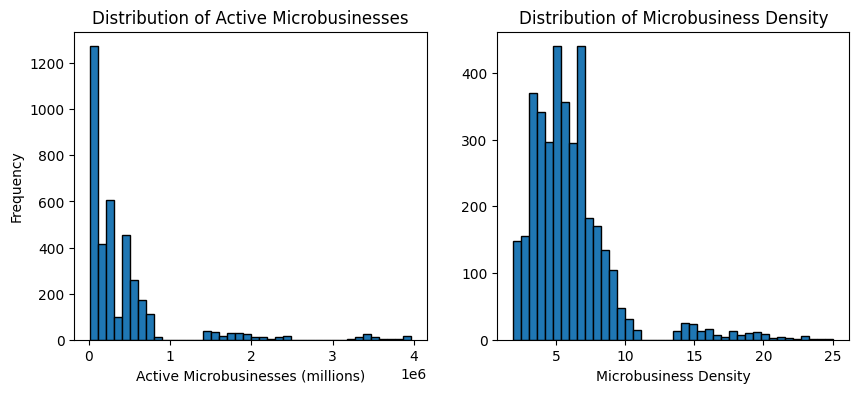

In [11]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))

ax[0].hist(df_state['Microbusinesses'], bins = 40, edgecolor = 'black');
ax[0].set_title('Distribution of Active Microbusinesses');
ax[0].set_xlabel('Active Microbusinesses (millions)');
ax[0].set_ylabel('Frequency');

ax[1].hist(df_state['Microbusiness Density'], bins = 40, edgecolor = 'black');
ax[1].set_title('Distribution of Microbusiness Density');
ax[1].set_xlabel('Microbusiness Density');

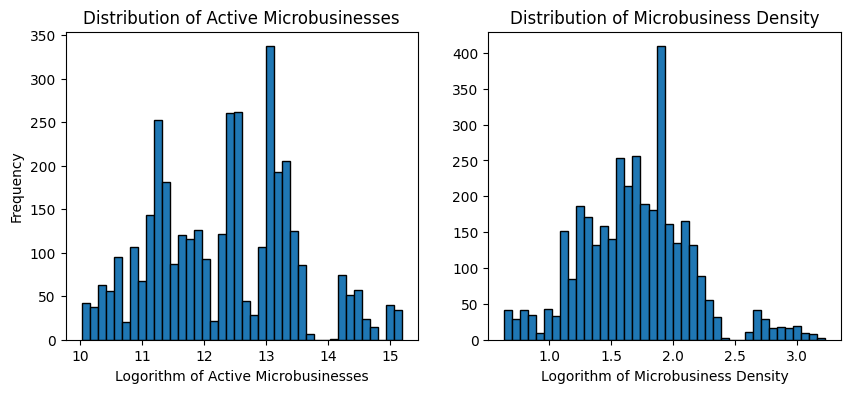

In [12]:
# Histograms with logorithmic transformations
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))

ax[0].hist(np.log(df_state['Microbusinesses']), bins = 40, edgecolor = 'black');
ax[0].set_title('Distribution of Active Microbusinesses');
ax[0].set_xlabel('Logorithm of Active Microbusinesses');
ax[0].set_ylabel('Frequency');

ax[1].hist(np.log(df_state['Microbusiness Density']), bins = 40, edgecolor = 'black');
ax[1].set_title('Distribution of Microbusiness Density');
ax[1].set_xlabel('Logorithm of Microbusiness Density');

Boxplots for the Active Microbusinesses and Microbusiness Density

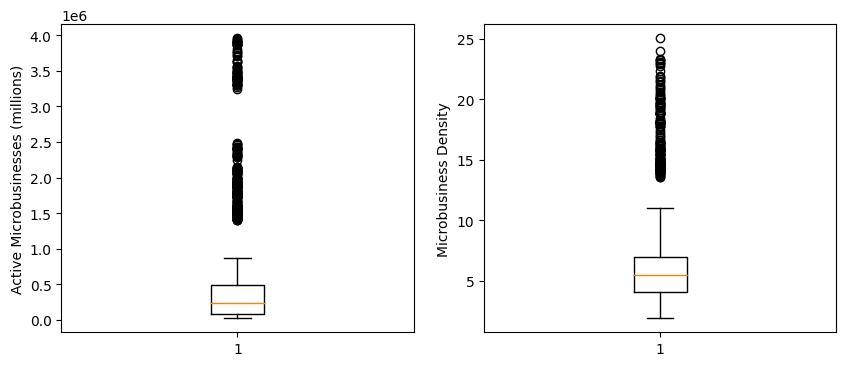

In [13]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))

micro_df1 = [df_state['Microbusinesses']]
ax[0].boxplot(micro_df1);
ax[0].set_ylabel('Active Microbusinesses (millions)');

micro_df2 = [df_state['Microbusiness Density']]
ax[1].boxplot(micro_df2);
ax[1].set_ylabel('Microbusiness Density');

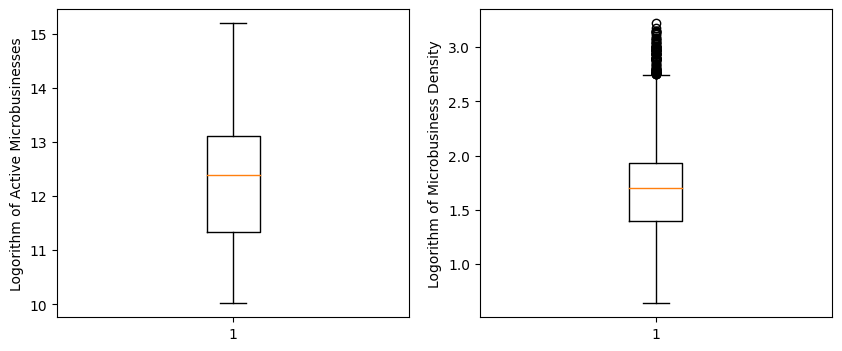

In [14]:
#Boxplots with logarithmic transformations
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))

micro_df1 = [np.log(df_state['Microbusinesses'])]
ax[0].boxplot(micro_df1);
ax[0].set_ylabel('Logorithm of Active Microbusinesses');

micro_df2 = [np.log(df_state['Microbusiness Density'])]
ax[1].boxplot(micro_df2);
ax[1].set_ylabel('Logorithm of Microbusiness Density');

Time Series Analysis for the Active Microbusinesses and Microbusiness Density

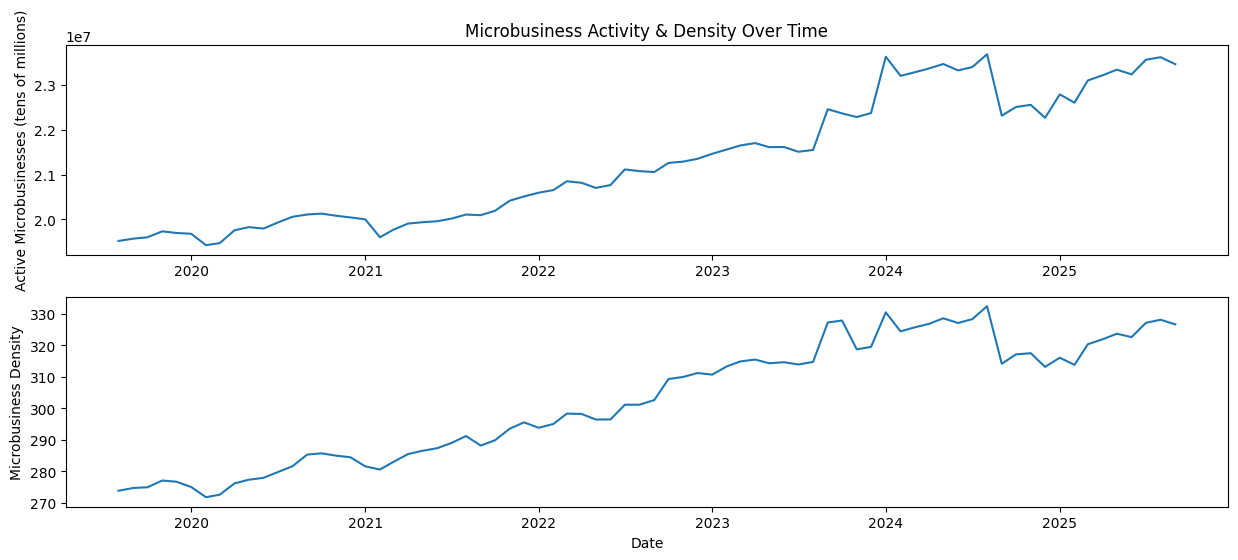

In [116]:
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (15, 6))

df_micro = df_state[['Date', 'Microbusinesses']]
df_micro.set_index('Date', inplace = True)

monthly_data = df_micro.resample('MS').sum()

ax[0].plot(monthly_data.index.values, monthly_data['Microbusinesses'].values)
#ax[0].plot(df_state['Date'].values, df_state['Microbusinesses'].values);
ax[0].set_title('Microbusiness Activity & Density Over Time');
#ax[0].set_xlabel('Date');
ax[0].set_ylabel('Active Microbusinesses (tens of millions)');

df_density = df_state[['Date', 'Microbusiness Density']]
df_density.set_index('Date', inplace = True)

monthly_data = df_density.resample('MS').sum()

ax[1].plot(monthly_data.index.values, monthly_data['Microbusiness Density'].values)

#ax[1].plot(df_state['Date'].values, df_state['Microbusiness Density'].values);
#ax[1].set_title('Microbusiness Density Over Time');
ax[1].set_xlabel('Date');
ax[1].set_ylabel('Microbusiness Density');

In [ ]:
# Write rearranged microbusiness dataset to your local directory
df_state.to_csv('df_state.csv', index = False)

## EDA County-Level Microbusiness Data

In [18]:
df_countyLevel.head()

,cfips,county,state,cfips_total_pop_2023,cfips_total_pop_2022,cfips_total_pop_2021,cfips_total_pop_2020,cfips_total_pop_2019,cfips_total_pop_2018,cfips_total_pop_2017,...,md_dec24,md_jan25,md_feb25,md_mar25,md_apr25,md_may25,md_jun25,md_jul25,md_aug25,md_sep25
0,1001,Autauga,AL,59285.0,58761.0,58239.0,55639.0,55380.0,55200.0,55036.0,...,3.384113,3.459071,3.463480,3.525210,3.549461,3.571507,3.567098,3.661897,3.686148,3.653079
1,1003,Baldwin,AL,239945.0,233420.0,227131.0,218289.0,212830.0,208107.0,203360.0,...,6.725560,6.859552,6.785406,7.075104,7.098937,7.102115,7.066101,7.190560,7.175201,7.178379
2,1005,Barbour,AL,24757.0,24877.0,25259.0,25026.0,25361.0,25782.0,26201.0,...,1.256641,1.277074,1.266857,1.323049,1.348590,1.317940,1.312832,1.358807,1.389456,1.384348
3,1007,Bibb,AL,22152.0,22251.0,22412.0,22374.0,22493.0,22527.0,22580.0,...,1.429863,1.446818,1.429863,1.582457,1.706793,1.718097,1.701142,1.740703,1.763310,1.712445
4,1009,Blount,AL,59292.0,59077.0,58884.0,57755.0,57681.0,57645.0,57667.0,...,1.666154,1.690302,1.670545,1.740791,1.751767,1.758353,1.762743,1.784695,1.793476,1.813233


In [19]:
df_county = micro_rearrange(df_countyLevel, 'county', 'state', state_level = False)
df_county['county'] = df_county['county'] + ' County, ' + df_county['state']
del df_county['state']

In [20]:
#display the first five rows of the dataset
df_county.head()

,cfips,county,Date,Microbusinesses,Microbusiness Density
0,1001,"Autauga County, AL",2019-08-01,1249,2.985824
1,1003,"Baldwin County, AL",2019-08-01,11464,7.057810
2,1005,"Barbour County, AL",2019-08-01,222,1.091124
3,1007,"Bibb County, AL",2019-08-01,234,1.309604
4,1009,"Blount County, AL",2019-08-01,681,1.541526


In [21]:
#gather information about the dataset (i.e. number of missing values and data types)
df_county.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231990 entries, 0 to 231989
Data columns (total 5 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   cfips                  231990 non-null  int64         
 1   county                 231990 non-null  object        
 2   Date                   231990 non-null  datetime64[ns]
 3   Microbusinesses        231990 non-null  int64         
 4   Microbusiness Density  231521 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 8.8+ MB


In [22]:
#check for duplicate rows
duplicated_rows_df = df_county[df_county.duplicated()]
print('There are {0} duplicates in this dataset'.format(duplicated_rows_df.shape[0]))

There are 0 duplicates in this dataset


In [23]:
#generate descriptive statistics for the date, microbusinesses, and microbusiness density
df_county.describe()

,cfips,Date,Microbusinesses,Microbusiness Density
count,231990.000000,231990,2.319900e+05,231521.000000
mean,30385.979904,2022-08-16 11:59:59.999999488,6.692376e+03,3.946434
min,1001.000000,2019-08-01 00:00:00,0.000000e+00,0.000000
25%,18179.000000,2021-02-01 00:00:00,1.480000e+02,1.683477
50%,29175.000000,2022-08-16 12:00:00,5.000000e+02,2.626278
75%,45079.000000,2024-03-01 00:00:00,2.168000e+03,4.522761
max,56045.000000,2025-09-01 00:00:00,1.233122e+06,438.607147
std,15143.559882,NaN,3.430107e+04,7.368467


In [27]:
#generate descriptive statistics for the states
df_county.describe(include = ['object'])

,county
count,231990
unique,3135
top,"Autauga County, AL"
freq,74


In [28]:
df_county[df_county['Microbusinesses'] == 0]

,cfips,county,Date,Microbusinesses,Microbusiness Density
18344,48301,"Loving County, TX",2020-01-01,0,0.0
21479,48301,"Loving County, TX",2020-02-01,0,0.0
24614,48301,"Loving County, TX",2020-03-01,0,0.0
57855,28055,"Issaquena County, MS",2021-02-01,0,0.0
59099,48301,"Loving County, TX",2021-02-01,0,0.0
60990,28055,"Issaquena County, MS",2021-03-01,0,0.0
62234,48301,"Loving County, TX",2021-03-01,0,0.0
64125,28055,"Issaquena County, MS",2021-04-01,0,0.0
67260,28055,"Issaquena County, MS",2021-05-01,0,0.0
70395,28055,"Issaquena County, MS",2021-06-01,0,0.0


In [29]:
df_county[df_county['Microbusiness Density'] == 0]

,cfips,county,Date,Microbusinesses,Microbusiness Density
18344,48301,"Loving County, TX",2020-01-01,0,0.0
21479,48301,"Loving County, TX",2020-02-01,0,0.0
24614,48301,"Loving County, TX",2020-03-01,0,0.0
57855,28055,"Issaquena County, MS",2021-02-01,0,0.0
59099,48301,"Loving County, TX",2021-02-01,0,0.0
60990,28055,"Issaquena County, MS",2021-03-01,0,0.0
62234,48301,"Loving County, TX",2021-03-01,0,0.0
64125,28055,"Issaquena County, MS",2021-04-01,0,0.0
67260,28055,"Issaquena County, MS",2021-05-01,0,0.0
70395,28055,"Issaquena County, MS",2021-06-01,0,0.0


Histograms for the Active Microbusinesses and Microbusiness Density

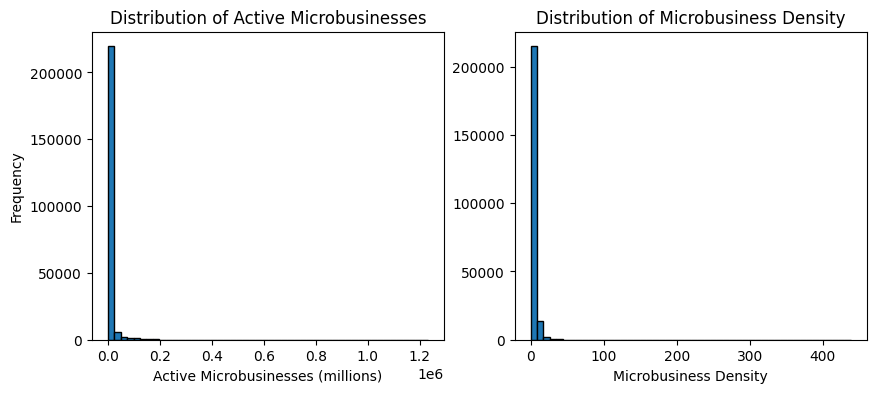

In [30]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))

ax[0].hist(df_county['Microbusinesses'], bins = 50, edgecolor = 'black');
ax[0].set_title('Distribution of Active Microbusinesses');
ax[0].set_xlabel('Active Microbusinesses (millions)');
ax[0].set_ylabel('Frequency');

ax[1].hist(df_county['Microbusiness Density'], bins = 50, edgecolor = 'black');
ax[1].set_title('Distribution of Microbusiness Density');
ax[1].set_xlabel('Microbusiness Density');

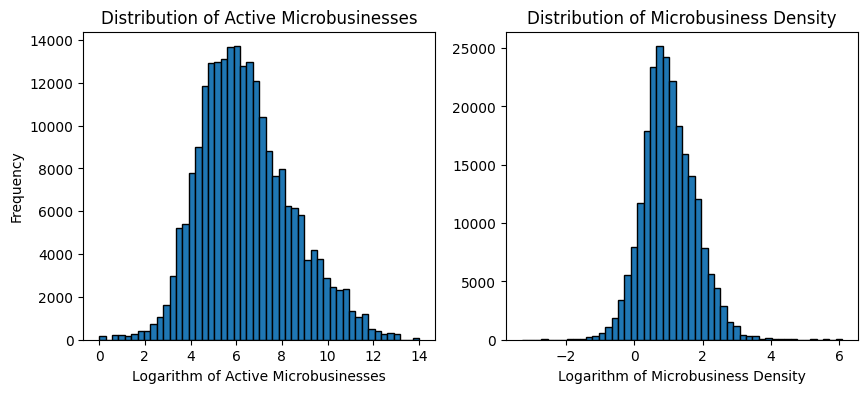

In [31]:
# Histograms with logarithmic transformation
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))

df_county_log = df_county.copy()
df_county_log['Microbusinesses'] = df_county_log['Microbusinesses'].replace(0, 1)
df_county_log['Microbusiness Density'] = df_county_log['Microbusiness Density'].replace(0, 1)

ax[0].hist(np.log(df_county_log['Microbusinesses']), bins = 50, edgecolor = 'black');
ax[0].set_title('Distribution of Active Microbusinesses');
ax[0].set_xlabel('Logarithm of Active Microbusinesses');
ax[0].set_ylabel('Frequency');

ax[1].hist(np.log(df_county_log['Microbusiness Density']), bins = 50, edgecolor = 'black');
ax[1].set_title('Distribution of Microbusiness Density');
ax[1].set_xlabel('Logarithm of Microbusiness Density');

Boxplots for the Active Microbusinesses and Microbusiness Density

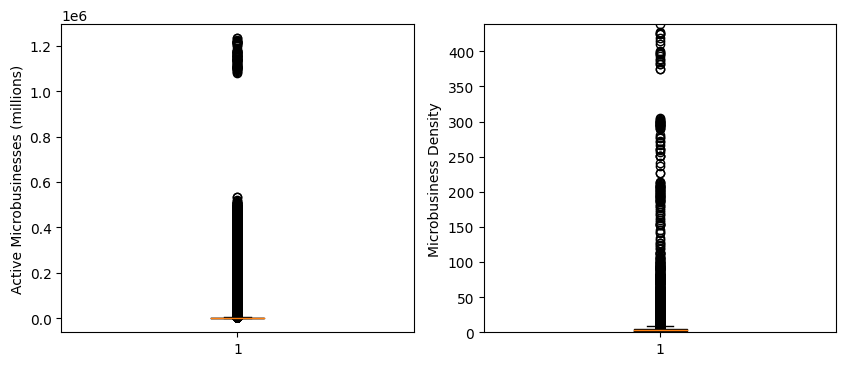

In [32]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))

micro_df1 = [df_county['Microbusinesses']]
ax[0].boxplot(micro_df1);
ax[0].set_ylabel('Active Microbusinesses (millions)');

micro_df2 = [df_county['Microbusiness Density'].dropna()]
ax[1].boxplot(micro_df2);
ax[1].set_ylabel('Microbusiness Density');
ax[1].set_ylim((df_county['Microbusiness Density'].min(), df_county['Microbusiness Density'].max()));

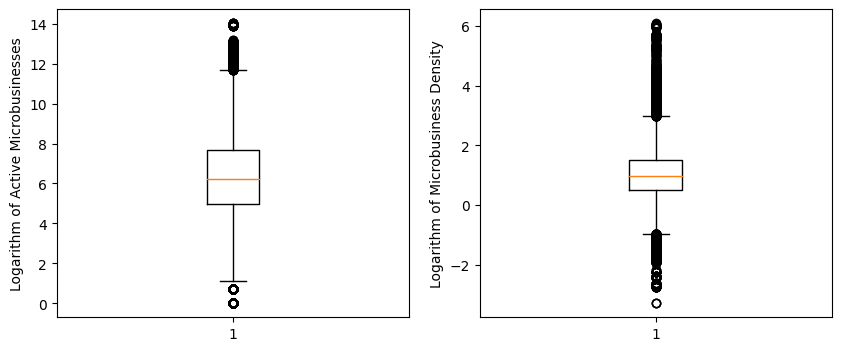

In [33]:
#Boxplots with logarithmic transformation
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))

micro_df1 = [np.log(df_county_log['Microbusinesses'])]
ax[0].boxplot(micro_df1);
ax[0].set_ylabel('Logarithm of Active Microbusinesses');

micro_df2 = [np.log(df_county_log['Microbusiness Density'].dropna())]
ax[1].boxplot(micro_df2);
ax[1].set_ylabel('Logarithm of Microbusiness Density');

Time Series Analysis for Active Microbusinesses and Microbusiness Density

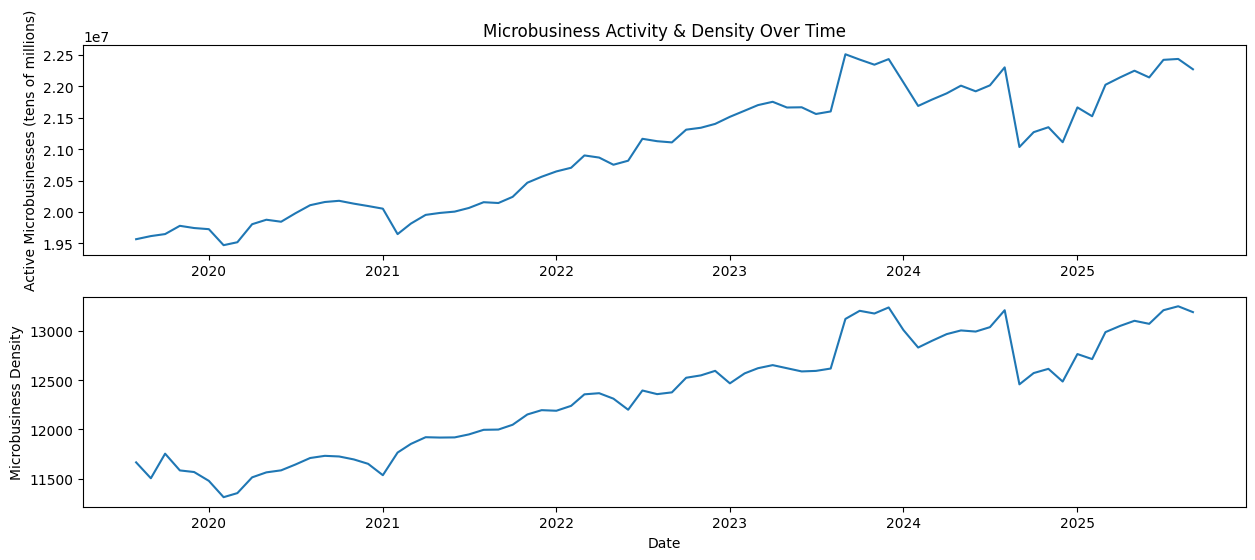

In [117]:
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (15, 6))

df_micro = df_county[['Date', 'Microbusinesses']]
df_micro.set_index('Date', inplace = True)

monthly_data = df_micro.resample('MS').sum()

ax[0].plot(monthly_data.index.values, monthly_data['Microbusinesses'].values)
#ax[0].plot(df_state['Date'].values, df_state['Microbusinesses'].values);
ax[0].set_title('Microbusiness Activity & Density Over Time');
#ax[0].set_xlabel('Date');
ax[0].set_ylabel('Active Microbusinesses (tens of millions)');

df_density = df_county[['Date', 'Microbusiness Density']]
df_density.set_index('Date', inplace = True)

monthly_data = df_density.resample('MS').sum()

ax[1].plot(monthly_data.index.values, monthly_data['Microbusiness Density'].values)

#ax[1].plot(df_state['Date'].values, df_state['Microbusiness Density'].values);
#ax[1].set_title('Microbusiness Density Over Time');
ax[1].set_xlabel('Date');
ax[1].set_ylabel('Microbusiness Density');

In [ ]:
df_county.to_csv('df_county.csv', index = False)

## EDA City-Level Microbusiness Data

In [35]:
df_cityLevel.head()

,cbsa,city_name,micro_metro,cbsa_total_pop_2022,cbsa_total_pop_2021,cbsa_total_pop_2020,cbsa_total_pop_2019,cbsa_total_pop_2018,cbsa_total_pop_2017,cbsa_pop18over_2022,...,md_mar25,md_apr25,md_may25,md_jun25,md_jul25,md_aug25,md_sep25,Unnamed: 163,Unnamed: 164,Unnamed: 165
0,49820,"Zapata, TX",Micropolitan Statistical Area,13896,13945,13896,14304,14369.0,14415.0,9363,...,0.598099,0.630140,0.619460,0.630140,0.630140,0.619460,0.651501,NaN,NaN,NaN
1,46900,"Vernon, TX",Micropolitan Statistical Area,12795,12887,12795,12833,12906.0,12972.0,9881,...,1.042405,1.042405,1.052525,1.082886,1.093007,1.153729,1.133489,NaN,NaN,NaN
2,22620,"Forrest City, AR",Micropolitan Statistical Area,23138,23623,23138,25900,26294.0,26688.0,18209,...,0.653523,0.659015,0.664507,0.648031,0.648031,0.659015,0.719424,NaN,NaN,NaN
3,25820,"Hereford, TX",Micropolitan Statistical Area,18585,18675,18585,18736,18899.0,18947.0,12861,...,0.979706,1.049685,1.080787,1.080787,1.026359,1.049685,1.041910,NaN,NaN,NaN
4,29500,"Lamesa, TX",Micropolitan Statistical Area,12342,12371,12342,12813,12964.0,13095.0,9199,...,1.434939,1.424068,1.402326,1.402326,1.456680,1.478422,1.413197,NaN,NaN,NaN


In [36]:
df_city = micro_rearrange(df_cityLevel, 'city_name', 'micro_metro', state_level = False)

In [37]:
#display the first five rows of the dataset
df_city.head()

,cbsa,city_name,micro_metro,Date,Microbusinesses,Microbusiness Density
0,49820,"Zapata, TX",Micropolitan Statistical Area,2019-08-01,35,0.367107
1,46900,"Vernon, TX",Micropolitan Statistical Area,2019-08-01,104,1.040520
2,22620,"Forrest City, AR",Micropolitan Statistical Area,2019-08-01,124,0.604259
3,25820,"Hereford, TX",Micropolitan Statistical Area,2019-08-01,123,0.948854
4,29500,"Lamesa, TX",Micropolitan Statistical Area,2019-08-01,176,1.795918


In [38]:
#gather information about the dataset (i.e. number of missing values and data types)
df_city.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68524 entries, 0 to 68523
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   cbsa                   68524 non-null  int64         
 1   city_name              68524 non-null  object        
 2   micro_metro            68524 non-null  object        
 3   Date                   68524 non-null  datetime64[ns]
 4   Microbusinesses        68524 non-null  int64         
 5   Microbusiness Density  68454 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 3.1+ MB


In [39]:
#check for duplicate rows
duplicated_rows_df = df_city[df_city.duplicated()]
print('There are {0} duplicates in this dataset'.format(duplicated_rows_df.shape[0]))

There are 0 duplicates in this dataset


In [40]:
#generate descriptive statistics for the date, microbusinesses, and microbusiness density
df_city.describe()

,cbsa,Date,Microbusinesses,Microbusiness Density
count,68524.000000,68524,6.852400e+04,68454.000000
mean,29821.757019,2022-08-16 12:00:00,2.223090e+04,4.958852
min,10100.000000,2019-08-01 00:00:00,3.500000e+01,0.367107
25%,20060.000000,2021-02-01 00:00:00,7.920000e+02,2.261617
50%,29800.000000,2022-08-16 12:00:00,2.121500e+03,3.275345
75%,39580.000000,2024-03-01 00:00:00,7.920000e+03,5.465394
max,49820.000000,2025-09-01 00:00:00,1.802748e+06,438.691882
std,11358.843829,NaN,1.015584e+05,11.028287


In [44]:
#generate descriptive statistics for the states
df_city.describe(include = ['object'])

,city_name,micro_metro
count,68524,68524
unique,926,2
top,"Zapata, TX",Micropolitan Statistical Area
freq,74,40108


Histograms for Active Microbusinesses and Microbusiness Density

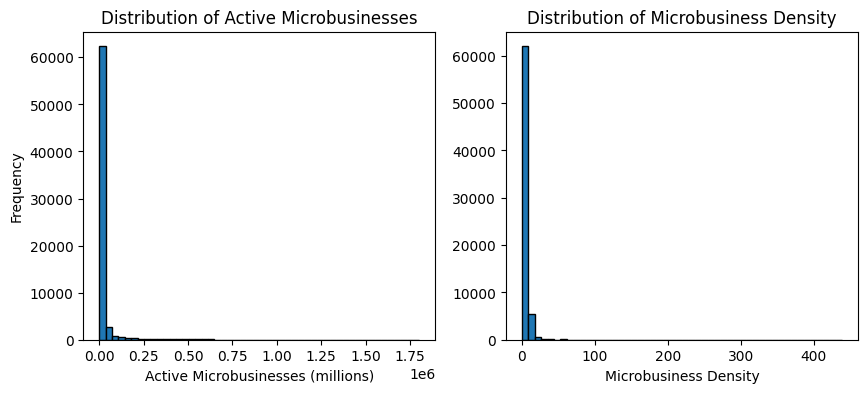

In [45]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))

ax[0].hist(df_city['Microbusinesses'], bins = 50, edgecolor = 'black');
ax[0].set_title('Distribution of Active Microbusinesses');
ax[0].set_xlabel('Active Microbusinesses (millions)');
ax[0].set_ylabel('Frequency');

ax[1].hist(df_city['Microbusiness Density'], bins = 50, edgecolor = 'black');
ax[1].set_title('Distribution of Microbusiness Density');
ax[1].set_xlabel('Microbusiness Density');

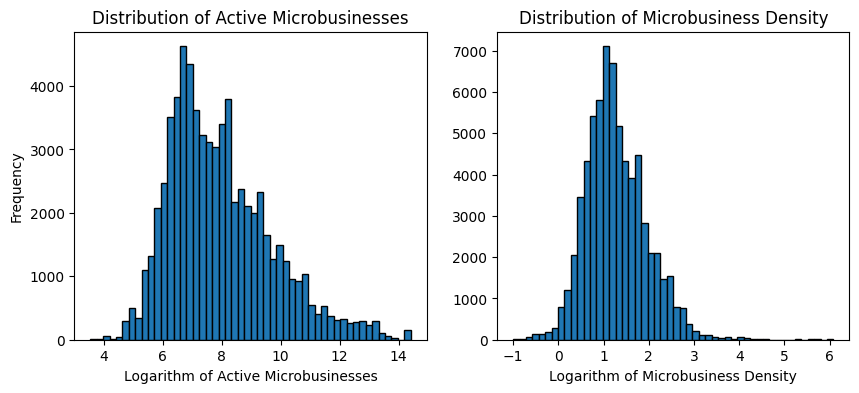

In [46]:
#Histograms with logarithmic transformations
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))

ax[0].hist(np.log(df_city['Microbusinesses']), bins = 50, edgecolor = 'black');
ax[0].set_title('Distribution of Active Microbusinesses');
ax[0].set_xlabel('Logarithm of Active Microbusinesses');
ax[0].set_ylabel('Frequency');

ax[1].hist(np.log(df_city['Microbusiness Density']), bins = 50, edgecolor = 'black');
ax[1].set_title('Distribution of Microbusiness Density');
ax[1].set_xlabel('Logarithm of Microbusiness Density');

Boxplots for the Active Microbusinesses and Microbusiness Density

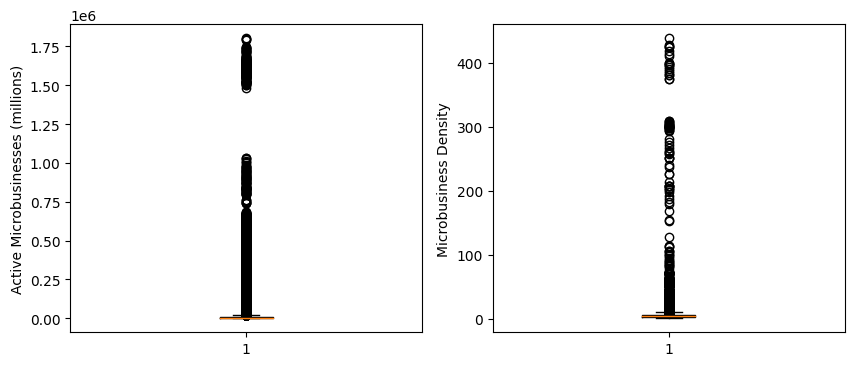

In [47]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))

micro_df1 = [df_city['Microbusinesses']]
ax[0].boxplot(micro_df1);
ax[0].set_ylabel('Active Microbusinesses (millions)');

micro_df2 = [df_city['Microbusiness Density'].dropna()]
ax[1].boxplot(micro_df2);
ax[1].set_ylabel('Microbusiness Density');

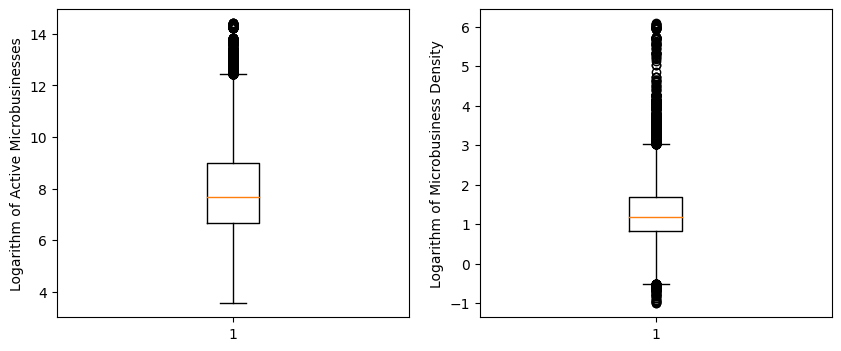

In [48]:
#Boxplots with logarithmic transformations
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))

micro_df1 = [np.log(df_city['Microbusinesses'])]
ax[0].boxplot(micro_df1);
ax[0].set_ylabel('Logarithm of Active Microbusinesses');

micro_df2 = [np.log(df_city['Microbusiness Density'].dropna())]
ax[1].boxplot(micro_df2);
ax[1].set_ylabel('Logarithm of Microbusiness Density');

Time Series Analysis for the Active Microbusinesses and Microbusiness Density

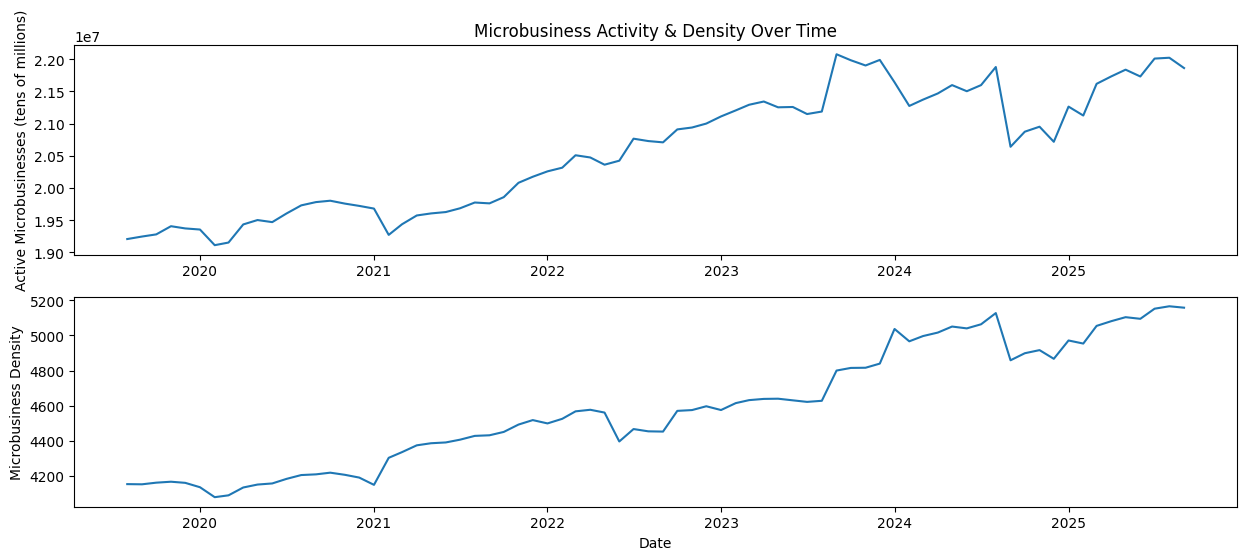

In [118]:
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (15, 6))

df_micro = df_city[['Date', 'Microbusinesses']]
df_micro.set_index('Date', inplace = True)

monthly_data = df_micro.resample('MS').sum()

ax[0].plot(monthly_data.index.values, monthly_data['Microbusinesses'].values)
#ax[0].plot(df_state['Date'].values, df_state['Microbusinesses'].values);
ax[0].set_title('Microbusiness Activity & Density Over Time');
#ax[0].set_xlabel('Date');
ax[0].set_ylabel('Active Microbusinesses (tens of millions)');

df_density = df_city[['Date', 'Microbusiness Density']]
df_density.set_index('Date', inplace = True)

monthly_data = df_density.resample('MS').sum()

ax[1].plot(monthly_data.index.values, monthly_data['Microbusiness Density'].values)

#ax[1].plot(df_state['Date'].values, df_state['Microbusiness Density'].values);
#ax[1].set_title('Microbusiness Density Over Time');
ax[1].set_xlabel('Date');
ax[1].set_ylabel('Microbusiness Density');

In [ ]:
df_city.to_csv('df_city.csv', index = False)

## EDA for Microbusiness Activity Index at the State Level

In [50]:
df_mai_stateLevel.head()

,date,state,stateName,wgtIndex_baseline,wgtIndex_baseline_engagement,wgtIndex_baseline_participation,wgtIndex_baseline_infrastructure,wgtIndex_even,wgtIndex_even_engagement,wgtIndex_even_participation,wgtIndex_even_infrastructure,wgtIndex_simple
0,2020-04-01,1,Alabama,93.64,97.41,97.10,92.78,95.20,98.27,97.19,92.42,86.31
1,2020-04-01,2,Alaska,102.94,97.14,100.45,107.02,102.17,99.48,100.48,107.07,101.95
2,2020-04-01,4,Arizona,100.63,94.73,103.34,100.68,101.91,96.85,103.23,100.66,124.67
3,2020-04-01,5,Arkansas,94.66,99.20,97.72,92.86,95.75,100.12,97.81,90.76,82.70
4,2020-04-01,6,California,103.11,100.65,102.88,102.20,102.33,97.84,102.77,102.57,124.56


In [51]:
#gather information about the dataset (i.e. number of missing values and data types)
df_mai_stateLevel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   date                              3333 non-null   datetime64[ns]
 1   state                             3333 non-null   int64         
 2   stateName                         3333 non-null   object        
 3   wgtIndex_baseline                 3333 non-null   float64       
 4   wgtIndex_baseline_engagement      3333 non-null   float64       
 5   wgtIndex_baseline_participation   3333 non-null   float64       
 6   wgtIndex_baseline_infrastructure  3333 non-null   float64       
 7   wgtIndex_even                     3333 non-null   float64       
 8   wgtIndex_even_engagement          3333 non-null   float64       
 9   wgtIndex_even_participation       3333 non-null   float64       
 10  wgtIndex_even_infrastructure      3333 non-null 

In [52]:
#check for duplicate rows
duplicated_rows_df = df_mai_stateLevel[df_mai_stateLevel.duplicated()]
print('There are {0} duplicates in this dataset'.format(duplicated_rows_df.shape[0]))

There are 0 duplicates in this dataset


In [53]:
#generate descriptive statistics for the date and indices
df_mai_stateLevel.describe()

,date,state,wgtIndex_baseline,wgtIndex_baseline_engagement,wgtIndex_baseline_participation,wgtIndex_baseline_infrastructure,wgtIndex_even,wgtIndex_even_engagement,wgtIndex_even_participation,wgtIndex_even_infrastructure,wgtIndex_simple
count,3333,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,2022-12-21 16:18:34.671467008,29.158416,104.736016,107.495842,100.326490,103.939226,104.079556,109.491299,100.319541,104.491683,102.254353
min,2020-04-01 00:00:00,1.000000,91.430000,93.340000,80.090000,89.550000,89.390000,88.800000,80.110000,87.950000,66.770000
25%,2021-08-01 00:00:00,17.000000,102.080000,101.620000,98.730000,101.390000,101.990000,104.060000,98.790000,101.440000,89.140000
50%,2023-01-01 00:00:00,29.000000,104.440000,104.970000,100.420000,104.190000,104.060000,107.740000,100.410000,105.050000,102.400000
75%,2024-05-01 00:00:00,42.000000,106.850000,109.780000,101.920000,106.860000,106.190000,114.860000,101.880000,107.590000,113.920000
max,2025-09-01 00:00:00,56.000000,121.900000,143.100000,106.220000,116.520000,115.250000,129.800000,106.000000,117.690000,140.160000
std,NaN,15.629646,4.406615,9.508265,2.337189,4.252044,3.201903,7.588713,2.260541,4.741572,17.663679


In [54]:
#generate descriptive statistics for the states
df_mai_stateLevel.describe(include = ['object'])

,stateName
count,3333
unique,51
top,Alabama
freq,66


Histograms of the Microbusiness Activity Index at the State Level

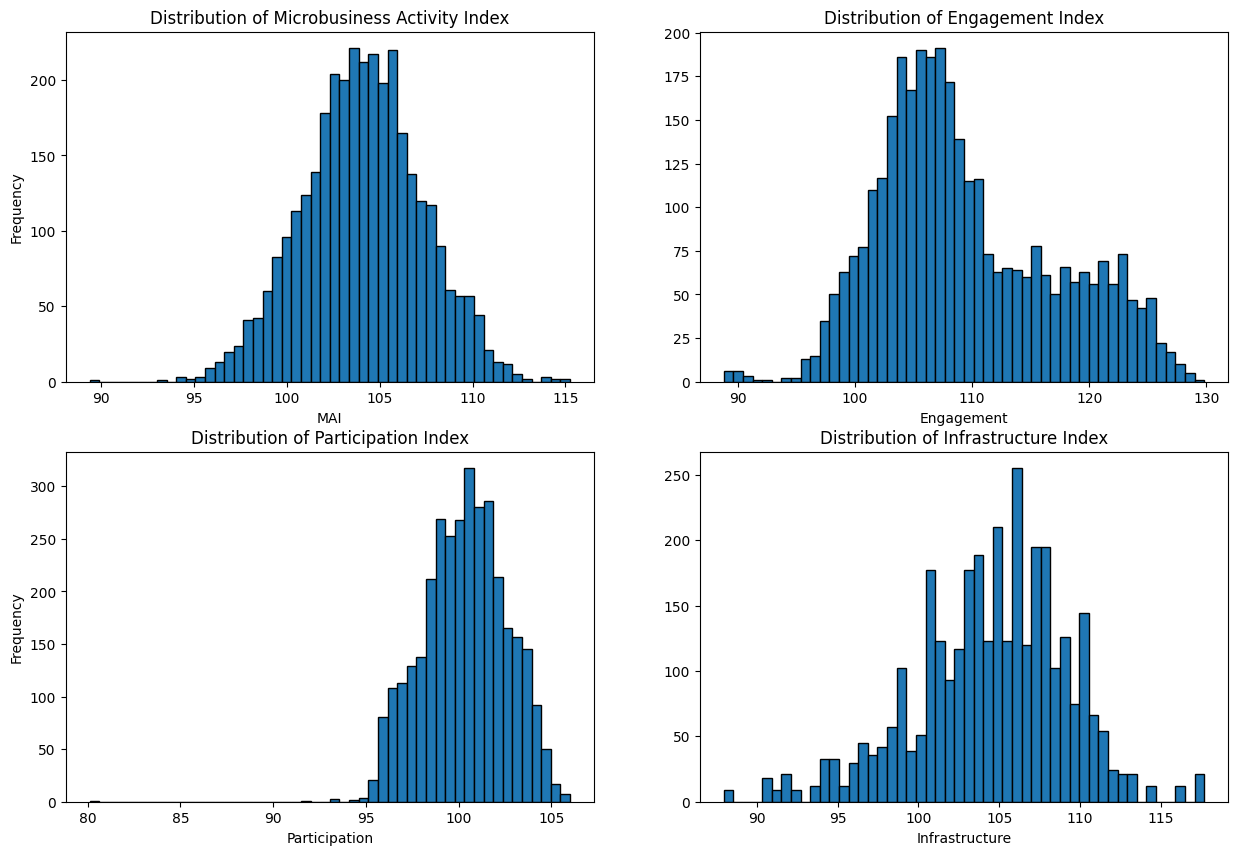

In [55]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (15, 10))

ax[0, 0].hist(df_mai_stateLevel['wgtIndex_even'], bins = 50, edgecolor = 'black');
ax[0, 0].set_title('Distribution of Microbusiness Activity Index');
ax[0, 0].set_xlabel('MAI');
ax[0, 0].set_ylabel('Frequency');

ax[0, 1].hist(df_mai_stateLevel['wgtIndex_even_engagement'], bins = 50, edgecolor = 'black');
ax[0, 1].set_title('Distribution of Engagement Index');
ax[0, 1].set_xlabel('Engagement');

ax[1, 0].hist(df_mai_stateLevel['wgtIndex_even_participation'], bins = 50, edgecolor = 'black');
ax[1, 0].set_title('Distribution of Participation Index');
ax[1, 0].set_xlabel('Participation');
ax[1, 0].set_ylabel('Frequency');

ax[1, 1].hist(df_mai_stateLevel['wgtIndex_even_infrastructure'], bins = 50, edgecolor = 'black');
ax[1, 1].set_title('Distribution of Infrastructure Index');
ax[1, 1].set_xlabel('Infrastructure');

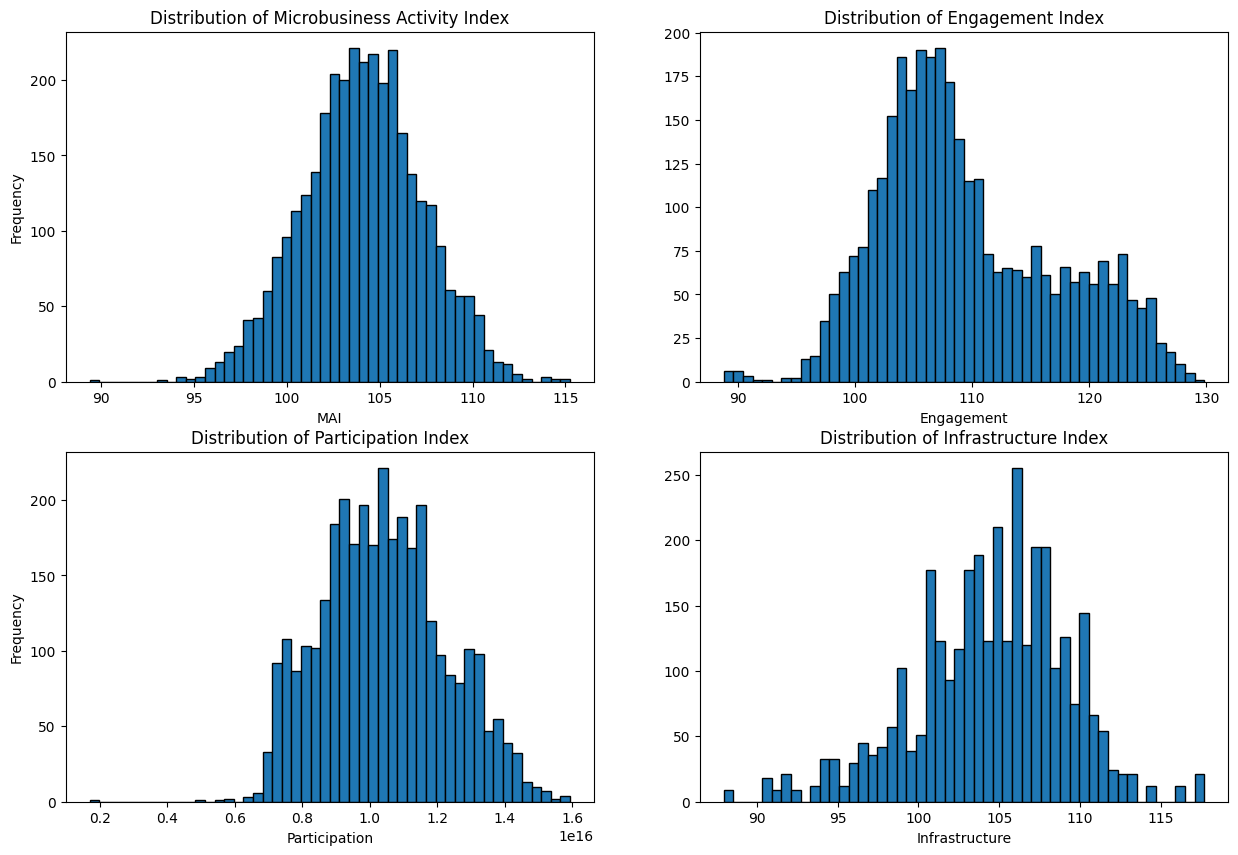

In [60]:
#Histograms with the participation index raised to the 8th power to reduce left skewness
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (15, 10))

ax[0, 0].hist(df_mai_stateLevel['wgtIndex_even'], bins = 50, edgecolor = 'black');
ax[0, 0].set_title('Distribution of Microbusiness Activity Index');
ax[0, 0].set_xlabel('MAI');
ax[0, 0].set_ylabel('Frequency');

ax[0, 1].hist(df_mai_stateLevel['wgtIndex_even_engagement'], bins = 50, edgecolor = 'black');
ax[0, 1].set_title('Distribution of Engagement Index');
ax[0, 1].set_xlabel('Engagement');

ax[1, 0].hist(np.power(df_mai_stateLevel['wgtIndex_even_participation'], 8), bins = 50, edgecolor = 'black');
ax[1, 0].set_title('Distribution of Participation Index');
ax[1, 0].set_xlabel('Participation');
ax[1, 0].set_ylabel('Frequency');

ax[1, 1].hist(df_mai_stateLevel['wgtIndex_even_infrastructure'], bins = 50, edgecolor = 'black');
ax[1, 1].set_title('Distribution of Infrastructure Index');
ax[1, 1].set_xlabel('Infrastructure');

Boxplots for the Microbusiness Activity Index at the State Level

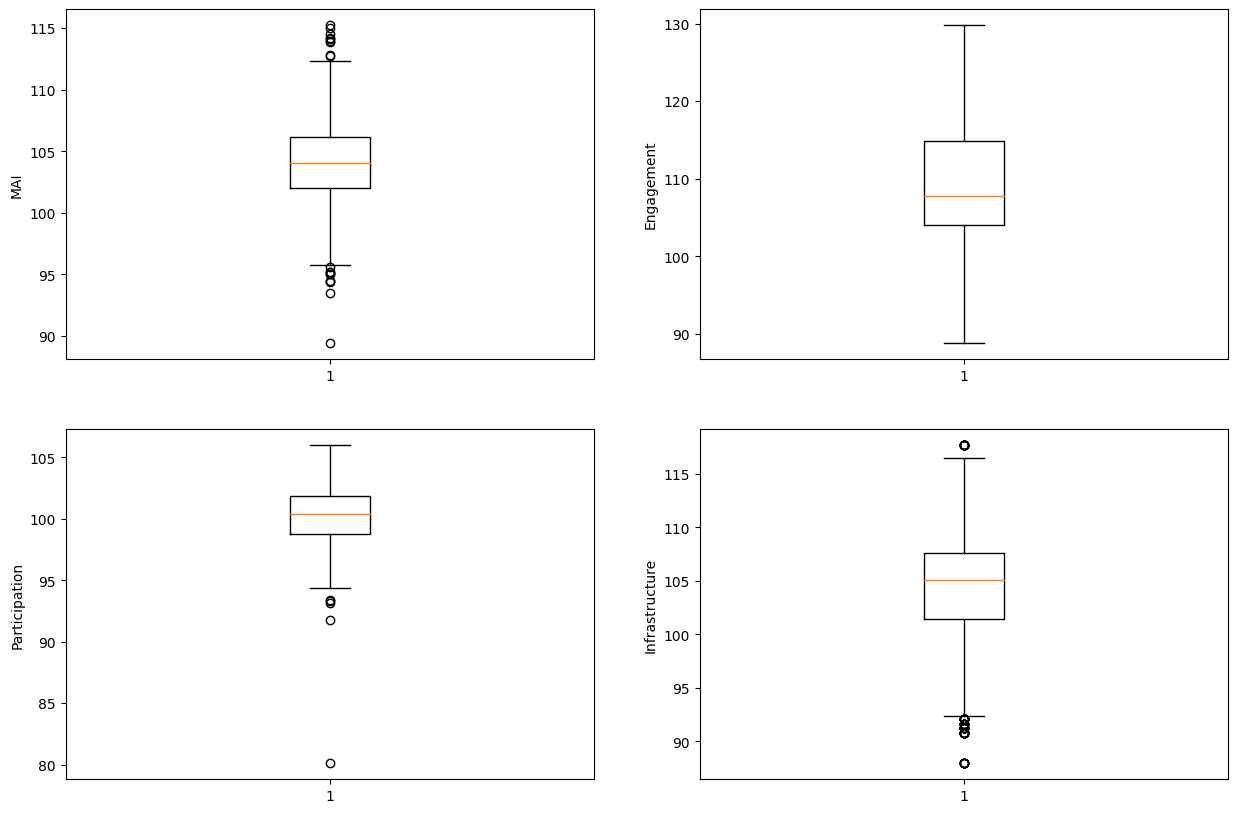

In [61]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (15, 10))

mai_df1 = [df_mai_stateLevel['wgtIndex_even']]
ax[0, 0].boxplot(mai_df1);
ax[0, 0].set_ylabel('MAI');

mai_df2 = [df_mai_stateLevel['wgtIndex_even_engagement']]
ax[0, 1].boxplot(mai_df2);
ax[0, 1].set_ylabel('Engagement');

mai_df3 = [df_mai_stateLevel['wgtIndex_even_participation']]
ax[1, 0].boxplot(mai_df3);
ax[1, 0].set_ylabel('Participation');

mai_df4 = [df_mai_stateLevel['wgtIndex_even_infrastructure']]
ax[1, 1].boxplot(mai_df4);
ax[1, 1].set_ylabel('Infrastructure');

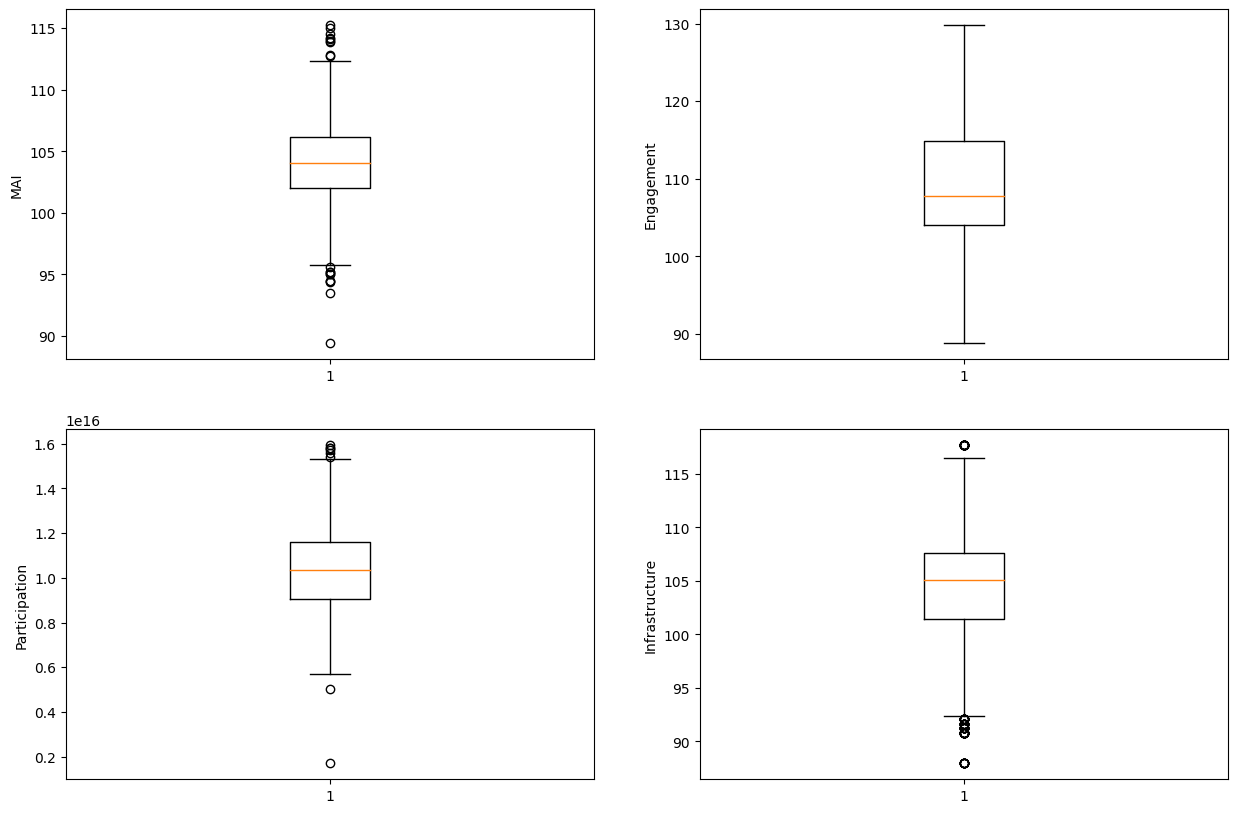

In [62]:
#Boxplots with the participation index raised to the 8th power to reduce left skewness
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (15, 10))

mai_df1 = [df_mai_stateLevel['wgtIndex_even']]
ax[0, 0].boxplot(mai_df1);
ax[0, 0].set_ylabel('MAI');

mai_df2 = [df_mai_stateLevel['wgtIndex_even_engagement']]
ax[0, 1].boxplot(mai_df2);
ax[0, 1].set_ylabel('Engagement');

mai_df3 = [np.power(df_mai_stateLevel['wgtIndex_even_participation'], 8)]
ax[1, 0].boxplot(mai_df3);
ax[1, 0].set_ylabel('Participation');

mai_df4 = [df_mai_stateLevel['wgtIndex_even_infrastructure']]
ax[1, 1].boxplot(mai_df4);
ax[1, 1].set_ylabel('Infrastructure');

Time Series Analysis for the Microbusiness Activity Index at the State Level

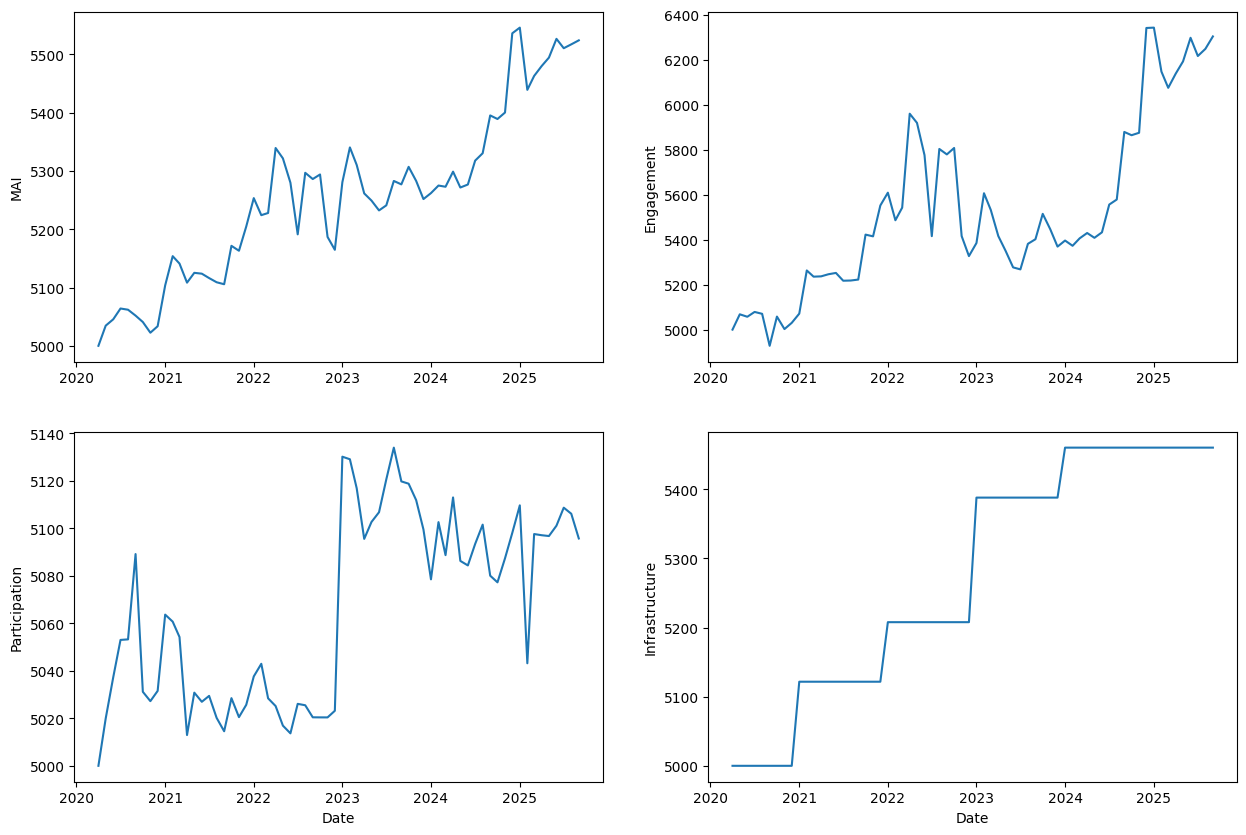

In [119]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (15, 10))

df_mai = df_mai_stateLevel[['date', 'wgtIndex_even']]
df_mai.set_index('date', inplace = True)

monthly_data = df_mai.resample('MS').sum()

ax[0, 0].plot(monthly_data.index.values, monthly_data['wgtIndex_even'].values)
ax[0, 0].set_ylabel('MAI');

df_engagement = df_mai_stateLevel[['date', 'wgtIndex_even_engagement']]
df_engagement.set_index('date', inplace = True)

monthly_data = df_engagement.resample('MS').sum()

ax[0, 1].plot(monthly_data.index.values, monthly_data['wgtIndex_even_engagement'].values)
ax[0, 1].set_ylabel('Engagement');

df_participation = df_mai_stateLevel[['date', 'wgtIndex_even_participation']]
df_participation.set_index('date', inplace = True)

monthly_data = df_participation.resample('MS').sum()

ax[1, 0].plot(monthly_data.index.values, monthly_data['wgtIndex_even_participation'].values)
ax[1, 0].set_xlabel('Date');
ax[1, 0].set_ylabel('Participation');

df_infrastructure = df_mai_stateLevel[['date', 'wgtIndex_even_infrastructure']]
df_infrastructure.set_index('date', inplace = True)

monthly_data = df_infrastructure.resample('MS').sum()

ax[1, 1].plot(monthly_data.index.values, monthly_data['wgtIndex_even_infrastructure'].values)
ax[1, 1].set_xlabel('Date');
ax[1, 1].set_ylabel('Infrastructure');

## EDA for Microbusiness Activity Index at the County Level

In [64]:
df_mai_countyLevel.head()

,date,county,countyName,wgtIndex_baseline,wgtIndex_baseline_engagement,wgtIndex_baseline_participation,wgtIndex_baseline_infrastructure,wgtIndex_even,wgtIndex_even_engagement,wgtIndex_even_participation,wgtIndex_even_infrastructure,wgtIndex_simple
0,2020-04-01,1001,"Autauga County, AL",99.90,93.06,98.94,106.02,97.85,89.77,98.90,106.53,102.14
1,2020-04-01,1003,"Baldwin County, AL",105.05,91.12,105.26,109.68,103.65,89.27,105.06,110.01,144.80
2,2020-04-01,1005,"Barbour County, AL",91.28,100.26,99.10,83.62,95.15,103.03,99.14,80.66,82.02
3,2020-04-01,1007,"Bibb County, AL",85.46,100.55,88.17,85.56,86.12,97.51,88.32,86.01,84.42
4,2020-04-01,1009,"Blount County, AL",94.82,98.39,100.49,90.22,97.91,99.33,100.54,91.00,88.50


In [65]:
#gather information about the dataset (i.e. number of missing values and data types)
df_mai_countyLevel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173052 entries, 0 to 173051
Data columns (total 12 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   date                              173052 non-null  datetime64[ns]
 1   county                            173052 non-null  int64         
 2   countyName                        172392 non-null  object        
 3   wgtIndex_baseline                 172689 non-null  float64       
 4   wgtIndex_baseline_engagement      173052 non-null  float64       
 5   wgtIndex_baseline_participation   172986 non-null  float64       
 6   wgtIndex_baseline_infrastructure  172722 non-null  float64       
 7   wgtIndex_even                     172689 non-null  float64       
 8   wgtIndex_even_engagement          173052 non-null  float64       
 9   wgtIndex_even_participation       172986 non-null  float64       
 10  wgtIndex_even_infrastructure    

In [100]:
df_mai_countyLevel = df_mai_countyLevel.dropna(subset = ['countyName'])

In [101]:
#check for duplicate rows
duplicated_rows_df = df_mai_countyLevel[df_mai_countyLevel.duplicated()]
print('There are {0} duplicates in this dataset'.format(duplicated_rows_df.shape[0]))

There are 0 duplicates in this dataset


In [102]:
#generate descriptive statistics for the date and indices
df_mai_countyLevel.describe()

,date,county,wgtIndex_baseline,wgtIndex_baseline_engagement,wgtIndex_baseline_participation,wgtIndex_baseline_infrastructure,wgtIndex_even,wgtIndex_even_engagement,wgtIndex_even_participation,wgtIndex_even_infrastructure,wgtIndex_simple
count,172392,172392.000000,172326.000000,172392.000000,172326.000000,172359.000000,172326.000000,172392.000000,172326.000000,172359.000000,172326.000000
mean,2022-12-16 17:05:27.272727040,30409.093415,106.015352,108.005871,100.696264,105.452571,104.855722,109.452420,100.685596,106.078026,104.742237
min,2020-04-01 00:00:00,1001.000000,35.610000,58.130000,11.640000,37.220000,23.550000,52.740000,11.350000,41.690000,72.780000
25%,2021-08-01 00:00:00,18144.500000,101.450000,101.060000,98.850000,99.800000,101.410000,102.670000,98.890000,99.760000,87.750000
50%,2022-12-16 12:00:00,29110.000000,106.070000,105.900000,100.520000,105.850000,105.040000,108.420000,100.550000,106.550000,96.410000
75%,2024-05-01 00:00:00,45053.500000,110.670000,111.690000,102.390000,111.770000,108.580000,116.150000,102.390000,113.090000,113.207500
max,2025-09-01 00:00:00,56045.000000,135.610000,158.130000,111.640000,137.220000,123.550000,152.740000,111.350000,141.690000,172.780000
std,NaN,15131.468716,7.364244,11.223901,3.300627,9.564012,5.556384,10.027886,3.228961,10.561256,24.542422


In [107]:
#generate descriptive statistics for the states
df_mai_countyLevel.describe(include = ['object'])

,countyName
count,172392
unique,2612
top,"Autauga County, AL"
freq,66


In [108]:
df_mai_countyLevel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 172392 entries, 0 to 173051
Data columns (total 12 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   date                              172392 non-null  datetime64[ns]
 1   county                            172392 non-null  int64         
 2   countyName                        172392 non-null  object        
 3   wgtIndex_baseline                 172326 non-null  float64       
 4   wgtIndex_baseline_engagement      172392 non-null  float64       
 5   wgtIndex_baseline_participation   172326 non-null  float64       
 6   wgtIndex_baseline_infrastructure  172359 non-null  float64       
 7   wgtIndex_even                     172326 non-null  float64       
 8   wgtIndex_even_engagement          172392 non-null  float64       
 9   wgtIndex_even_participation       172326 non-null  float64       
 10  wgtIndex_even_infrastructure      172

Histograms for the Microbusiness Activity Index at the County Level

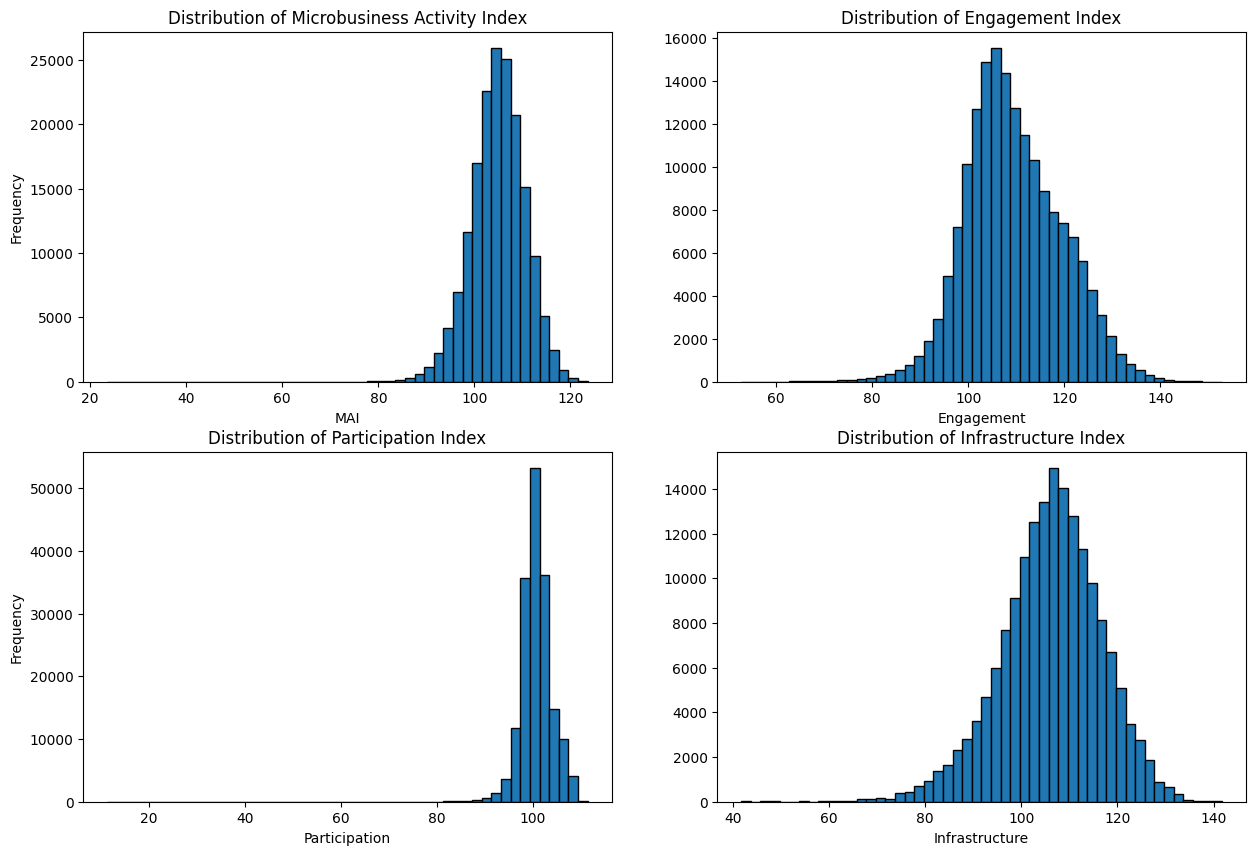

In [109]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (15, 10))

ax[0, 0].hist(df_mai_countyLevel['wgtIndex_even'], bins = 50, edgecolor = 'black');
ax[0, 0].set_title('Distribution of Microbusiness Activity Index');
ax[0, 0].set_xlabel('MAI');
ax[0, 0].set_ylabel('Frequency');

ax[0, 1].hist(df_mai_countyLevel['wgtIndex_even_engagement'], bins = 50, edgecolor = 'black');
ax[0, 1].set_title('Distribution of Engagement Index');
ax[0, 1].set_xlabel('Engagement');

ax[1, 0].hist(df_mai_countyLevel['wgtIndex_even_participation'], bins = 50, edgecolor = 'black');
ax[1, 0].set_title('Distribution of Participation Index');
ax[1, 0].set_xlabel('Participation');
ax[1, 0].set_ylabel('Frequency');

ax[1, 1].hist(df_mai_countyLevel['wgtIndex_even_infrastructure'], bins = 50, edgecolor = 'black');
ax[1, 1].set_title('Distribution of Infrastructure Index');
ax[1, 1].set_xlabel('Infrastructure');

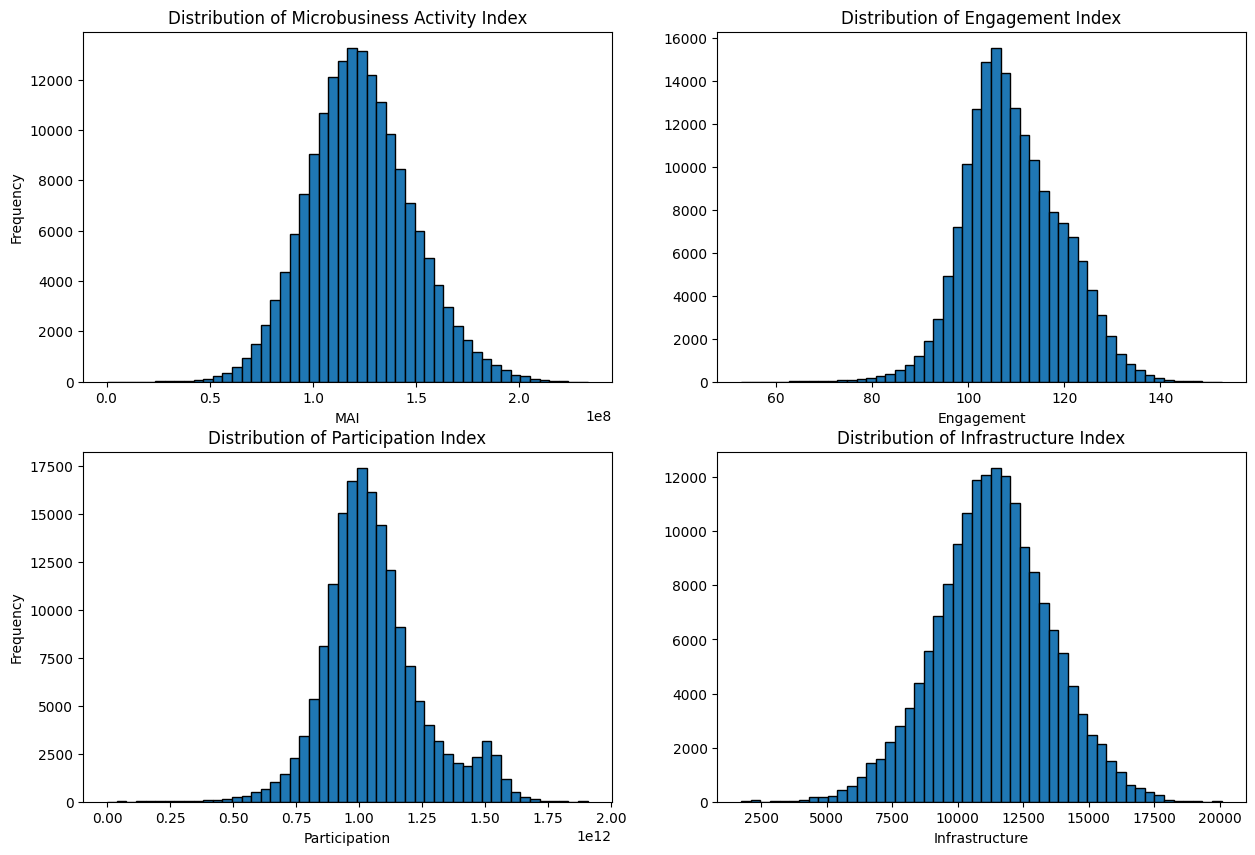

In [110]:
#Histograms with data transformations to reduce left-skewness 
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (15, 10))

ax[0, 0].hist(np.power(df_mai_countyLevel['wgtIndex_even'], 4), bins = 50, edgecolor = 'black');
ax[0, 0].set_title('Distribution of Microbusiness Activity Index');
ax[0, 0].set_xlabel('MAI');
ax[0, 0].set_ylabel('Frequency');

ax[0, 1].hist(df_mai_countyLevel['wgtIndex_even_engagement'], bins = 50, edgecolor = 'black');
ax[0, 1].set_title('Distribution of Engagement Index');
ax[0, 1].set_xlabel('Engagement');

ax[1, 0].hist(np.power(df_mai_countyLevel['wgtIndex_even_participation'], 6), bins = 50, edgecolor = 'black');
ax[1, 0].set_title('Distribution of Participation Index');
ax[1, 0].set_xlabel('Participation');
ax[1, 0].set_ylabel('Frequency');

ax[1, 1].hist(np.power(df_mai_countyLevel['wgtIndex_even_infrastructure'], 2), bins = 50, edgecolor = 'black');
ax[1, 1].set_title('Distribution of Infrastructure Index');
ax[1, 1].set_xlabel('Infrastructure');

Boxplots for the Microbusiness Activity Index at the County Level

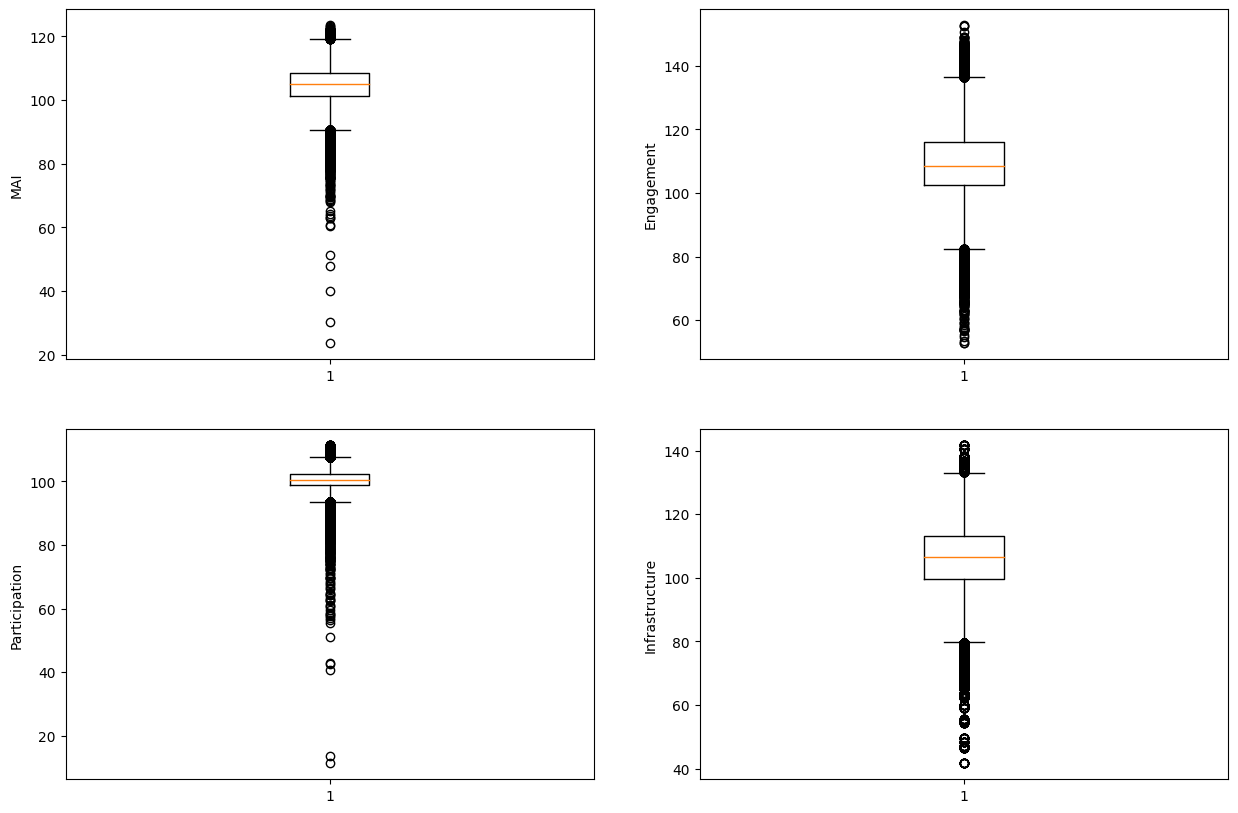

In [111]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (15, 10))

mai_df1 = [df_mai_countyLevel['wgtIndex_even'].dropna()]
ax[0, 0].boxplot(mai_df1);
ax[0, 0].set_ylabel('MAI');

mai_df2 = [df_mai_countyLevel['wgtIndex_even_engagement']]
ax[0, 1].boxplot(mai_df2);
ax[0, 1].set_ylabel('Engagement');

mai_df3 = [df_mai_countyLevel['wgtIndex_even_participation'].dropna()]
ax[1, 0].boxplot(mai_df3);
ax[1, 0].set_ylabel('Participation');

mai_df4 = [df_mai_countyLevel['wgtIndex_even_infrastructure'].dropna()]
ax[1, 1].boxplot(mai_df4);
ax[1, 1].set_ylabel('Infrastructure');

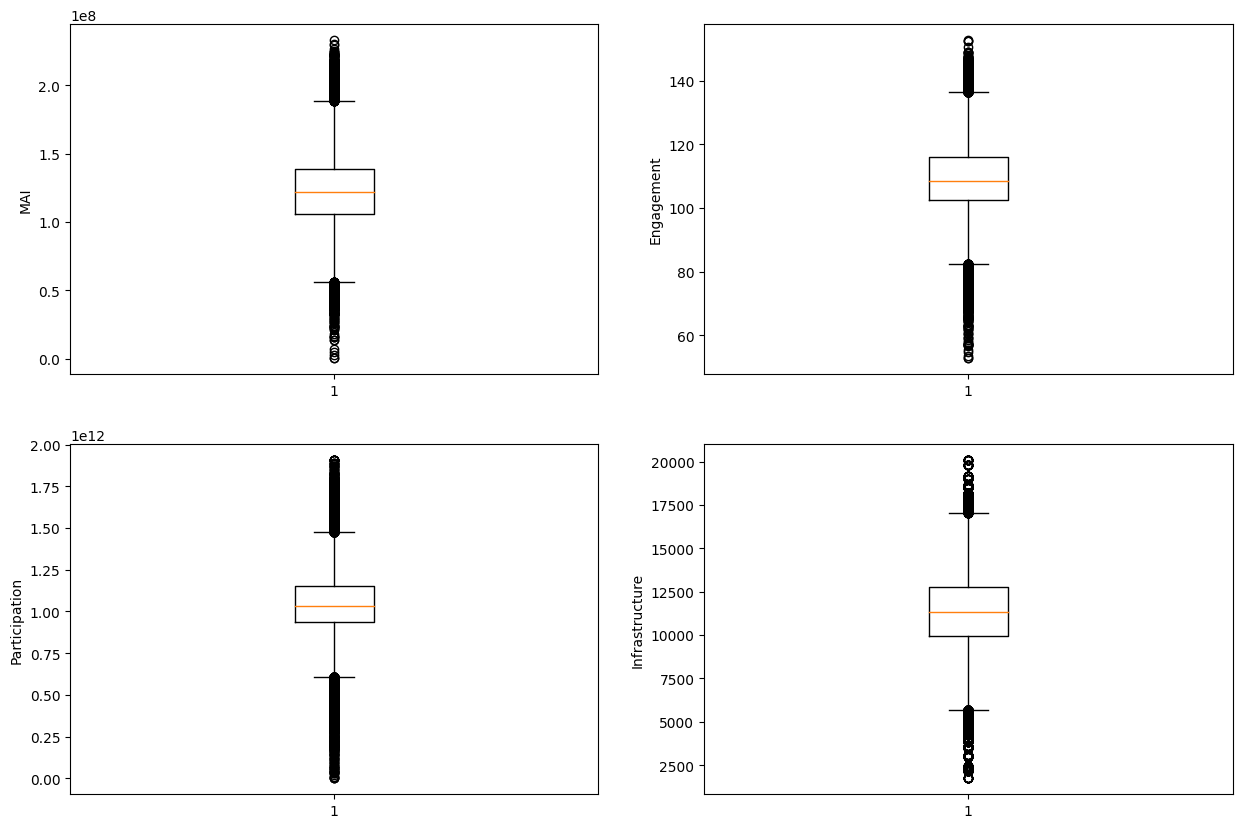

In [112]:
#Boxplots with data transformations to reduce left-skewness
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (15, 10))

mai_df1 = [np.power(df_mai_countyLevel['wgtIndex_even'].dropna(), 4)]
ax[0, 0].boxplot(mai_df1);
ax[0, 0].set_ylabel('MAI');

mai_df2 = [df_mai_countyLevel['wgtIndex_even_engagement']]
ax[0, 1].boxplot(mai_df2);
ax[0, 1].set_ylabel('Engagement');

mai_df3 = [np.power(df_mai_countyLevel['wgtIndex_even_participation'].dropna(), 6)]
ax[1, 0].boxplot(mai_df3);
ax[1, 0].set_ylabel('Participation');

mai_df4 = [np.power(df_mai_countyLevel['wgtIndex_even_infrastructure'].dropna(), 2)]
ax[1, 1].boxplot(mai_df4);
ax[1, 1].set_ylabel('Infrastructure');

Time Series Analysis for the Microbusiness Activity Index at the County Level

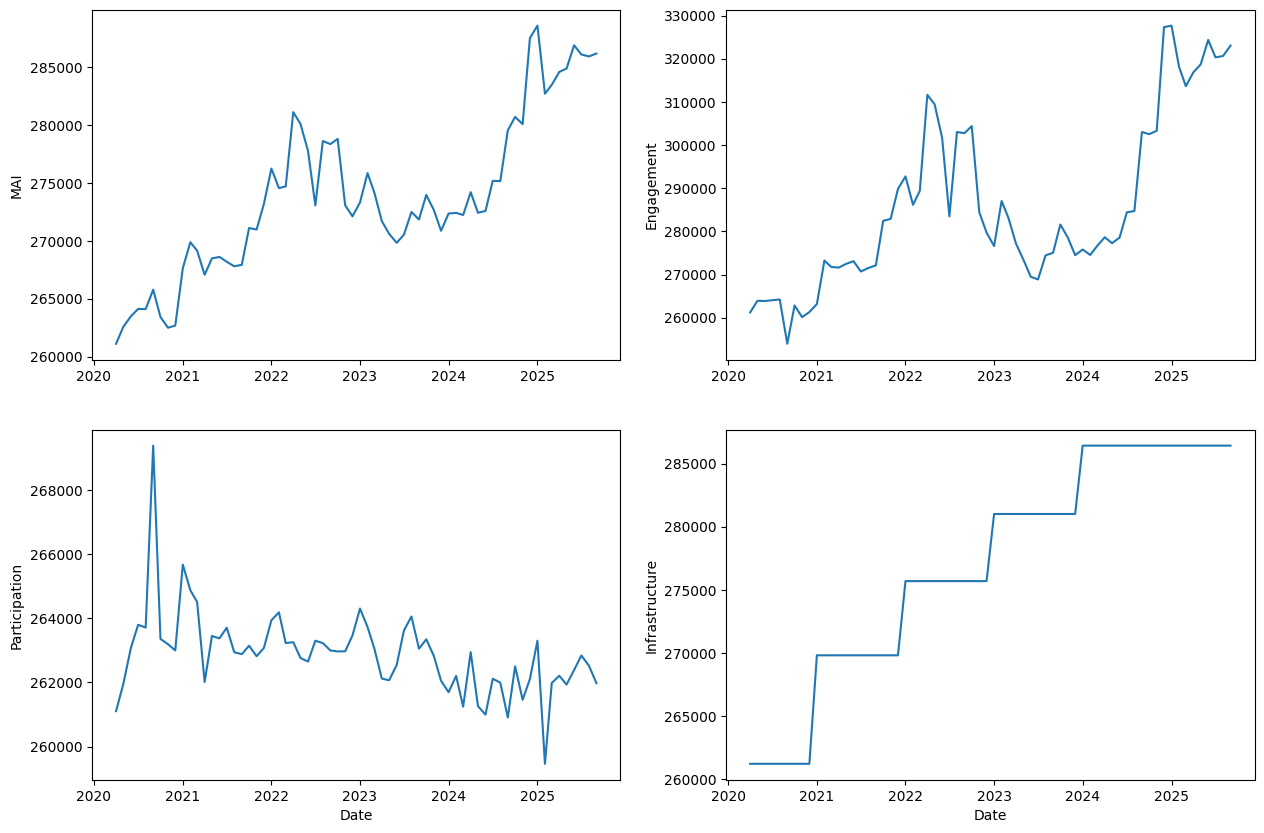

In [120]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (15, 10))

df_mai = df_mai_countyLevel[['date', 'wgtIndex_even']]
df_mai.set_index('date', inplace = True)

monthly_data = df_mai.resample('MS').sum()

ax[0, 0].plot(monthly_data.index.values, monthly_data['wgtIndex_even'].values)
ax[0, 0].set_ylabel('MAI');

df_engagement = df_mai_countyLevel[['date', 'wgtIndex_even_engagement']]
df_engagement.set_index('date', inplace = True)

monthly_data = df_engagement.resample('MS').sum()

ax[0, 1].plot(monthly_data.index.values, monthly_data['wgtIndex_even_engagement'].values)
ax[0, 1].set_ylabel('Engagement');

df_participation = df_mai_countyLevel[['date', 'wgtIndex_even_participation']]
df_participation.set_index('date', inplace = True)

monthly_data = df_participation.resample('MS').sum()

ax[1, 0].plot(monthly_data.index.values, monthly_data['wgtIndex_even_participation'].values)
ax[1, 0].set_xlabel('Date');
ax[1, 0].set_ylabel('Participation');

df_infrastructure = df_mai_countyLevel[['date', 'wgtIndex_even_infrastructure']]
df_infrastructure.set_index('date', inplace = True)

monthly_data = df_infrastructure.resample('MS').sum()

ax[1, 1].plot(monthly_data.index.values, monthly_data['wgtIndex_even_infrastructure'].values)
ax[1, 1].set_xlabel('Date');
ax[1, 1].set_ylabel('Infrastructure');

## EDA for Microbusiness Activity Index at the City Level

In [79]:
df_mai_cityLevel.head()

,date,cbsa,cbsaName,wgtIndex_baseline,wgtIndex_baseline_engagement,wgtIndex_baseline_participation,wgtIndex_baseline_infrastructure,wgtIndex_even,wgtIndex_even_engagement,wgtIndex_even_participation,wgtIndex_even_infrastructure,wgtIndex_simple
0,2020-04-01,10100,"Aberdeen, SD",100.96,106.43,95.70,102.80,100.51,110.83,95.78,103.24,85.38
1,2020-04-01,10140,"Aberdeen, WA",98.18,97.32,98.71,99.83,98.83,98.12,98.78,101.35,90.25
2,2020-04-01,10180,"Abilene, TX",99.99,98.08,99.56,101.84,99.20,98.05,99.58,100.38,96.34
3,2020-04-01,10220,"Ada, OK",100.49,100.85,100.17,100.18,99.64,101.27,100.15,96.78,98.50
4,2020-04-01,10300,"Adrian, MI",102.80,103.12,100.04,103.33,102.38,105.12,100.03,103.43,99.37


In [80]:
#gather information about the dataset (i.e. number of missing values and data types)
df_mai_cityLevel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60852 entries, 0 to 60851
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   date                              60852 non-null  datetime64[ns]
 1   cbsa                              60852 non-null  int64         
 2   cbsaName                          60852 non-null  object        
 3   wgtIndex_baseline                 60852 non-null  float64       
 4   wgtIndex_baseline_engagement      60852 non-null  float64       
 5   wgtIndex_baseline_participation   60852 non-null  float64       
 6   wgtIndex_baseline_infrastructure  60852 non-null  float64       
 7   wgtIndex_even                     60852 non-null  float64       
 8   wgtIndex_even_engagement          60852 non-null  float64       
 9   wgtIndex_even_participation       60852 non-null  float64       
 10  wgtIndex_even_infrastructure      60852 non-nu

In [81]:
#check for duplicate rows
duplicated_rows_df = df_mai_cityLevel[df_mai_cityLevel.duplicated()]
print('There are {0} duplicates in this dataset'.format(duplicated_rows_df.shape[0]))

There are 0 duplicates in this dataset


In [82]:
#generate descriptive statistics for the date and indices
df_mai_cityLevel.describe()

,date,cbsa,wgtIndex_baseline,wgtIndex_baseline_engagement,wgtIndex_baseline_participation,wgtIndex_baseline_infrastructure,wgtIndex_even,wgtIndex_even_engagement,wgtIndex_even_participation,wgtIndex_even_infrastructure,wgtIndex_simple
count,60852,60852.000000,60852.000000,60852.000000,60852.000000,60852.000000,60852.000000,60852.000000,60852.000000,60852.000000,60852.000000
mean,2022-12-16 17:05:27.272727808,29795.625813,105.463253,108.089888,100.223572,104.954712,104.292213,109.366276,100.217966,105.526394,101.828008
min,2020-04-01 00:00:00,10100.000000,75.380000,69.060000,56.970000,64.880000,68.710000,61.090000,57.470000,61.380000,69.110000
25%,2021-08-01 00:00:00,20020.000000,101.530000,101.450000,98.420000,100.480000,101.290000,102.980000,98.480000,100.750000,85.240000
50%,2022-12-16 12:00:00,29760.000000,105.330000,105.880000,99.800000,105.180000,104.340000,108.140000,99.830000,105.880000,94.000000
75%,2024-05-01 00:00:00,39580.000000,109.420000,111.180000,101.720000,110.150000,107.460000,115.450000,101.690000,111.272500,111.510000
max,2025-09-01 00:00:00,49820.000000,128.360000,153.550000,110.650000,129.730000,118.870000,145.700000,110.390000,132.660000,162.020000
std,NaN,11368.084015,6.266851,10.634670,2.834572,7.704877,4.634826,8.999264,2.751168,8.507495,22.895383


In [83]:
#generate descriptive statistics for the states
df_mai_cityLevel.describe(include = ['object'])

,cbsaName
count,60852
unique,922
top,"Aberdeen, SD"
freq,66


Histograms for the Microbusiness Activity Index at the City Level

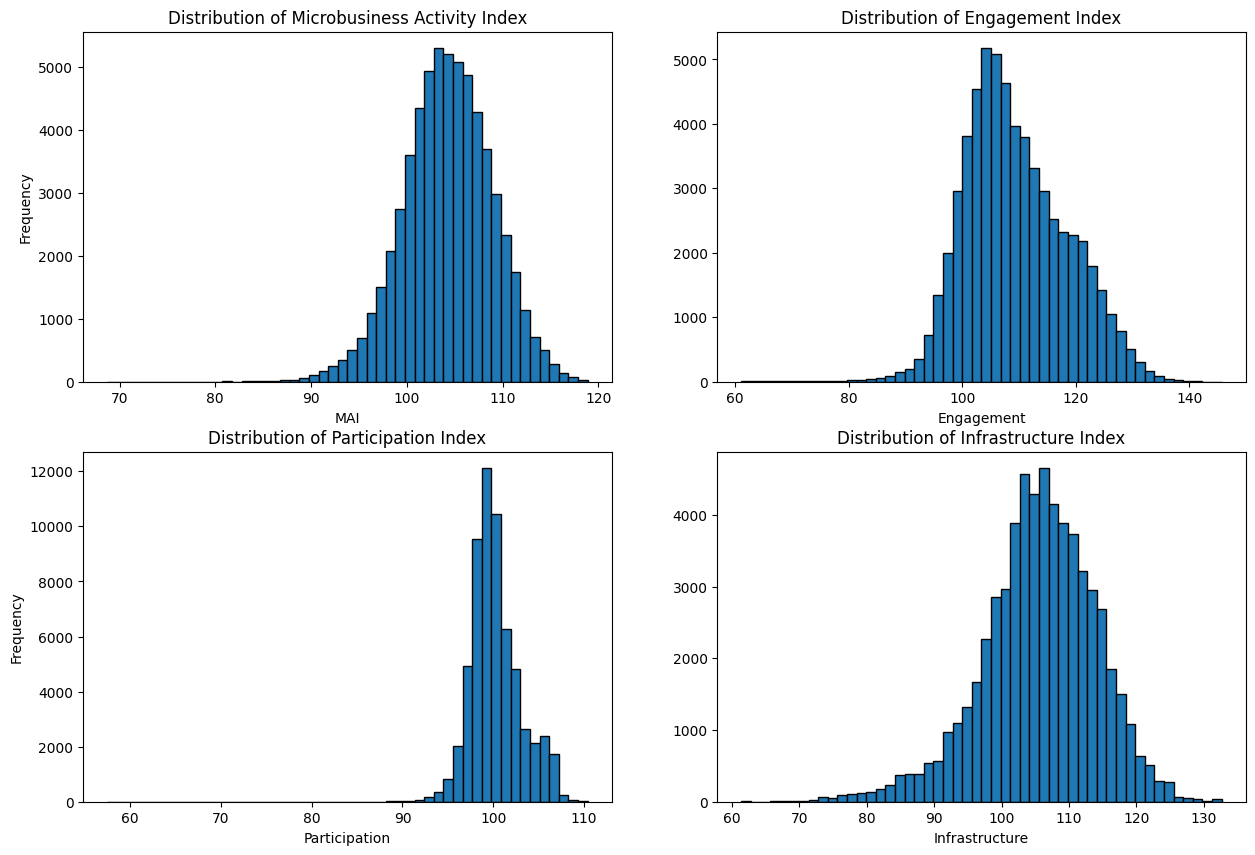

In [84]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (15, 10))

ax[0, 0].hist(df_mai_cityLevel['wgtIndex_even'], bins = 50, edgecolor = 'black');
ax[0, 0].set_title('Distribution of Microbusiness Activity Index');
ax[0, 0].set_xlabel('MAI');
ax[0, 0].set_ylabel('Frequency');

ax[0, 1].hist(df_mai_cityLevel['wgtIndex_even_engagement'], bins = 50, edgecolor = 'black');
ax[0, 1].set_title('Distribution of Engagement Index');
ax[0, 1].set_xlabel('Engagement');

ax[1, 0].hist(df_mai_cityLevel['wgtIndex_even_participation'], bins = 50, edgecolor = 'black');
ax[1, 0].set_title('Distribution of Participation Index');
ax[1, 0].set_xlabel('Participation');
ax[1, 0].set_ylabel('Frequency');

ax[1, 1].hist(df_mai_cityLevel['wgtIndex_even_infrastructure'], bins = 50, edgecolor = 'black');
ax[1, 1].set_title('Distribution of Infrastructure Index');
ax[1, 1].set_xlabel('Infrastructure');

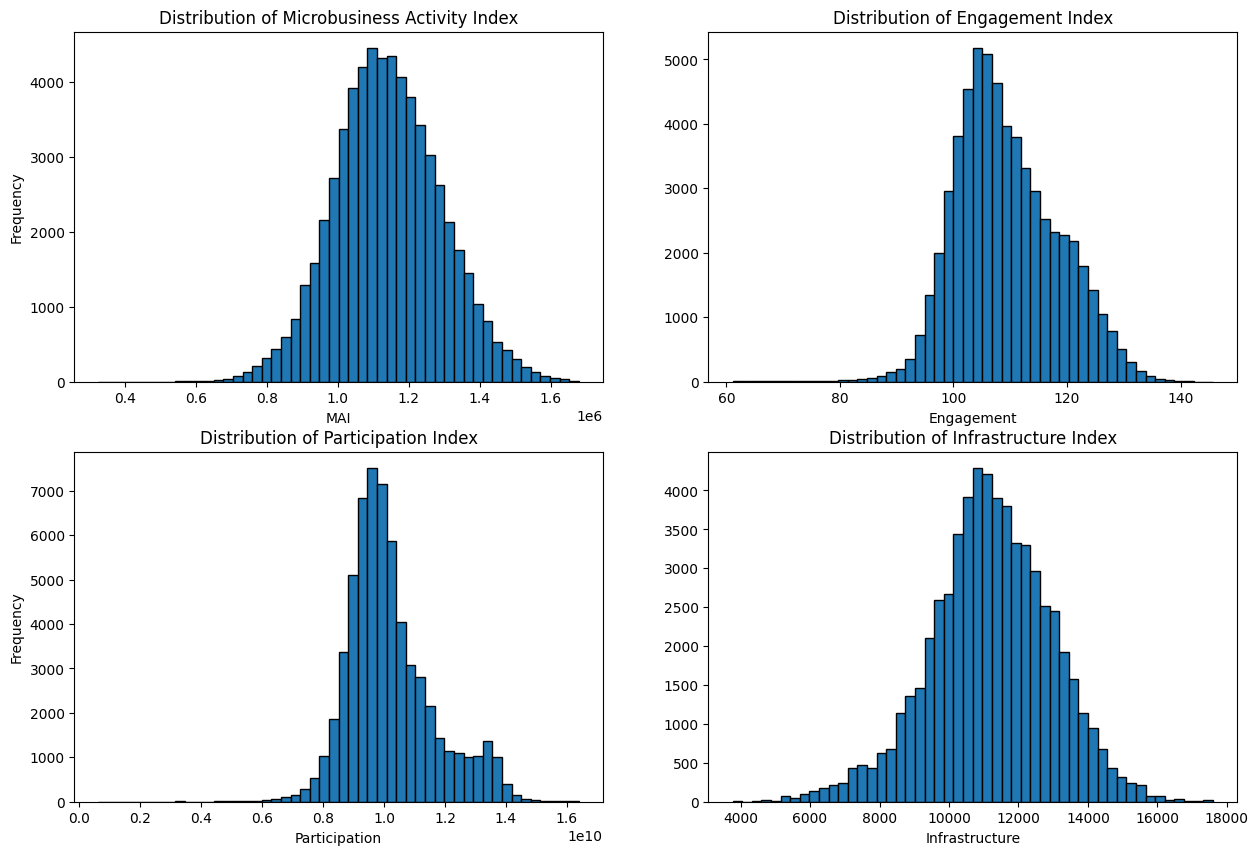

In [89]:
#Histograms with data transformations to reduce left-skewness
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (15, 10))

ax[0, 0].hist(np.power(df_mai_cityLevel['wgtIndex_even'], 3), bins = 50, edgecolor = 'black');
ax[0, 0].set_title('Distribution of Microbusiness Activity Index');
ax[0, 0].set_xlabel('MAI');
ax[0, 0].set_ylabel('Frequency');

ax[0, 1].hist(df_mai_cityLevel['wgtIndex_even_engagement'], bins = 50, edgecolor = 'black');
ax[0, 1].set_title('Distribution of Engagement Index');
ax[0, 1].set_xlabel('Engagement');

ax[1, 0].hist(np.power(df_mai_cityLevel['wgtIndex_even_participation'], 5), bins = 50, edgecolor = 'black');
ax[1, 0].set_title('Distribution of Participation Index');
ax[1, 0].set_xlabel('Participation');
ax[1, 0].set_ylabel('Frequency');

ax[1, 1].hist(np.power(df_mai_cityLevel['wgtIndex_even_infrastructure'], 2), bins = 50, edgecolor = 'black');
ax[1, 1].set_title('Distribution of Infrastructure Index');
ax[1, 1].set_xlabel('Infrastructure');

Boxplots for the Microbusiness Activity Index at the City Level

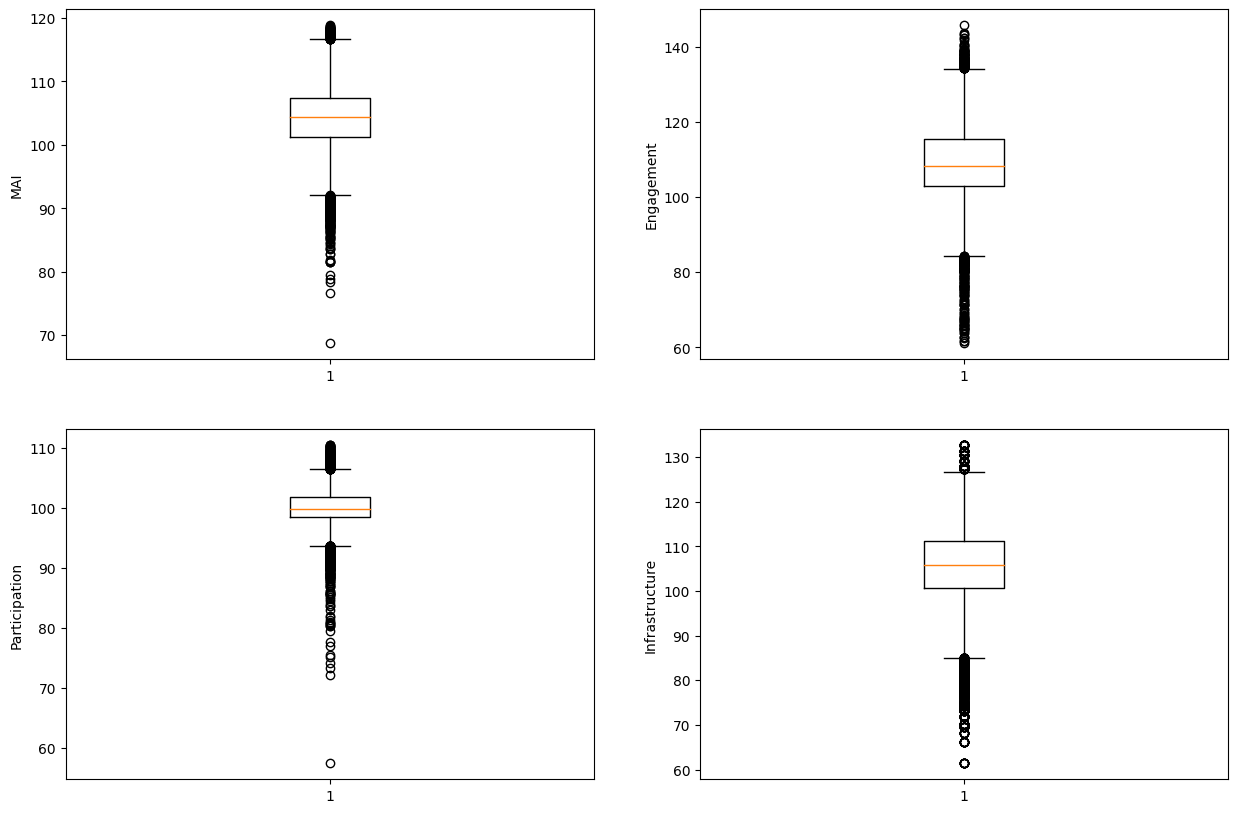

In [90]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (15, 10))

mai_df1 = [df_mai_cityLevel['wgtIndex_even']]
ax[0, 0].boxplot(mai_df1);
ax[0, 0].set_ylabel('MAI');

mai_df2 = [df_mai_cityLevel['wgtIndex_even_engagement']]
ax[0, 1].boxplot(mai_df2);
ax[0, 1].set_ylabel('Engagement');

mai_df3 = [df_mai_cityLevel['wgtIndex_even_participation']]
ax[1, 0].boxplot(mai_df3);
ax[1, 0].set_ylabel('Participation');

mai_df4 = [df_mai_cityLevel['wgtIndex_even_infrastructure']]
ax[1, 1].boxplot(mai_df4);
ax[1, 1].set_ylabel('Infrastructure');

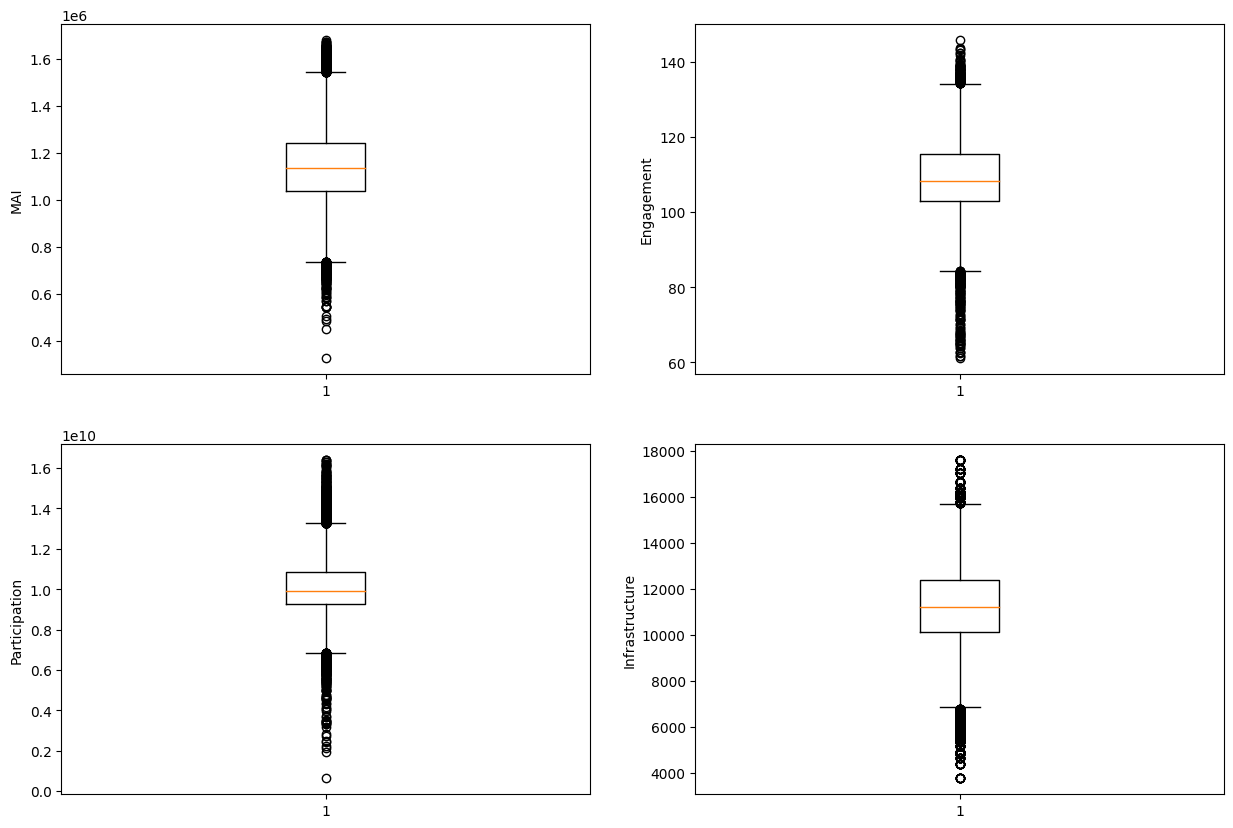

In [91]:
#Boxplots with data transformations to reduce left skewness
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (15, 10))

mai_df1 = [np.power(df_mai_cityLevel['wgtIndex_even'], 3)]
ax[0, 0].boxplot(mai_df1);
ax[0, 0].set_ylabel('MAI');

mai_df2 = [df_mai_cityLevel['wgtIndex_even_engagement']]
ax[0, 1].boxplot(mai_df2);
ax[0, 1].set_ylabel('Engagement');

mai_df3 = [np.power(df_mai_cityLevel['wgtIndex_even_participation'], 5)]
ax[1, 0].boxplot(mai_df3);
ax[1, 0].set_ylabel('Participation');

mai_df4 = [np.power(df_mai_cityLevel['wgtIndex_even_infrastructure'], 2)]
ax[1, 1].boxplot(mai_df4);
ax[1, 1].set_ylabel('Infrastructure');

Time Series Analysis for the Microbusiness Activity Index at the City Level

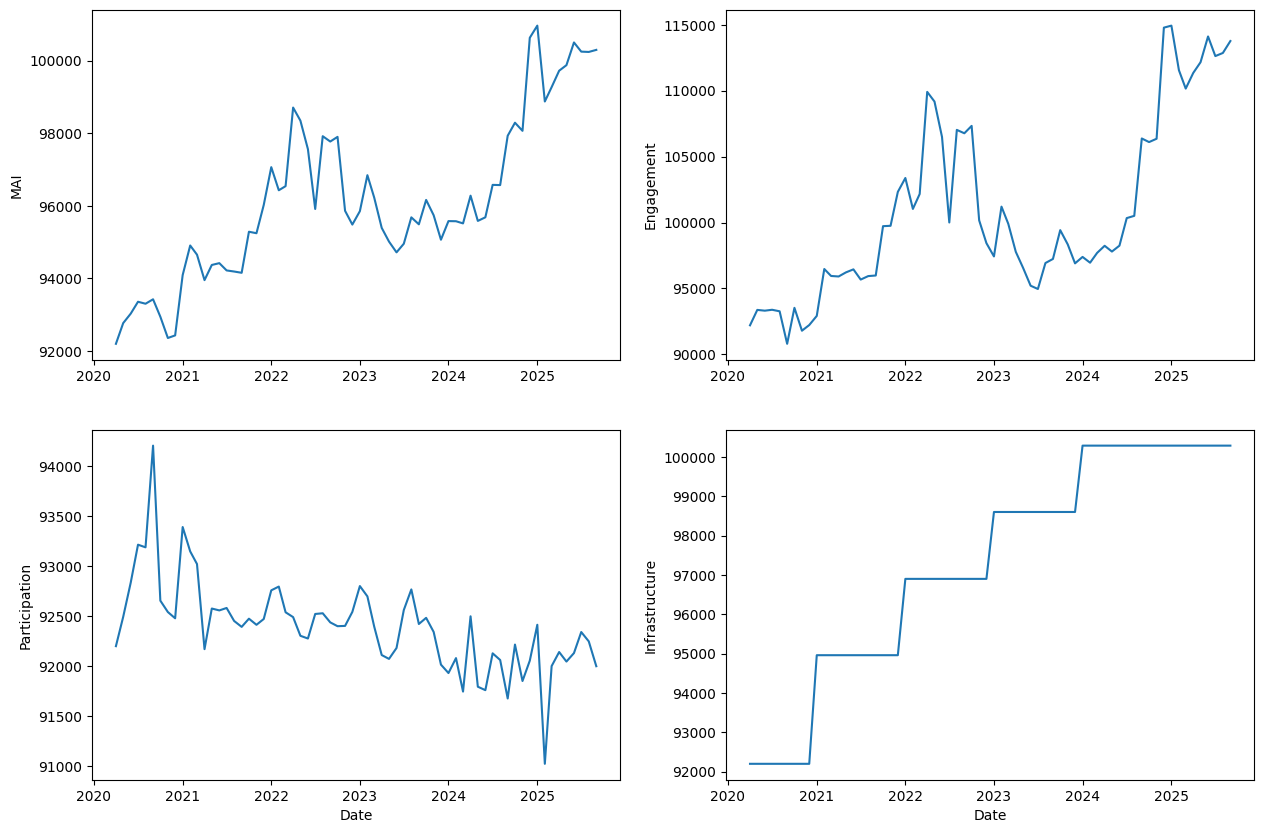

In [121]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (15, 10))

df_mai = df_mai_cityLevel[['date', 'wgtIndex_even']]
df_mai.set_index('date', inplace = True)

monthly_data = df_mai.resample('MS').sum()

ax[0, 0].plot(monthly_data.index.values, monthly_data['wgtIndex_even'].values)
ax[0, 0].set_ylabel('MAI');

df_engagement = df_mai_cityLevel[['date', 'wgtIndex_even_engagement']]
df_engagement.set_index('date', inplace = True)

monthly_data = df_engagement.resample('MS').sum()

ax[0, 1].plot(monthly_data.index.values, monthly_data['wgtIndex_even_engagement'].values)
ax[0, 1].set_ylabel('Engagement');

df_participation = df_mai_cityLevel[['date', 'wgtIndex_even_participation']]
df_participation.set_index('date', inplace = True)

monthly_data = df_participation.resample('MS').sum()

ax[1, 0].plot(monthly_data.index.values, monthly_data['wgtIndex_even_participation'].values)
ax[1, 0].set_xlabel('Date');
ax[1, 0].set_ylabel('Participation');

df_infrastructure = df_mai_cityLevel[['date', 'wgtIndex_even_infrastructure']]
df_infrastructure.set_index('date', inplace = True)

monthly_data = df_infrastructure.resample('MS').sum()

ax[1, 1].plot(monthly_data.index.values, monthly_data['wgtIndex_even_infrastructure'].values)
ax[1, 1].set_xlabel('Date');
ax[1, 1].set_ylabel('Infrastructure');

## Correlation Analysis at the State Level

In [93]:
df_mai_stateLevel2 = df_mai_stateLevel.rename(columns = {'stateName' : 'state_name', 'date' : 'Date'})
df_state_merge = pd.merge(df_state, df_mai_stateLevel2, on = ['Date', 'state_name'], how = 'outer')
df_state_merge.head()

,state_name,state_abbrev,Date,Microbusinesses,Microbusiness Density,state,wgtIndex_baseline,wgtIndex_baseline_engagement,wgtIndex_baseline_participation,wgtIndex_baseline_infrastructure,wgtIndex_even,wgtIndex_even_engagement,wgtIndex_even_participation,wgtIndex_even_infrastructure,wgtIndex_simple
0,Alaska,AK,2019-08-01,31005.0,4.198284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Alabama,AL,2019-08-01,146473.0,3.010948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arkansas,AR,2019-08-01,84119.0,2.812713,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arizona,AZ,2019-08-01,566930.0,8.161159,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,California,CA,2019-08-01,3399846.0,8.684428,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Heatmap for wgtIndex_even, wgtIndex_even_engagement, wgtIndex_even_participation, and wgtIndex_even_infrastructure.

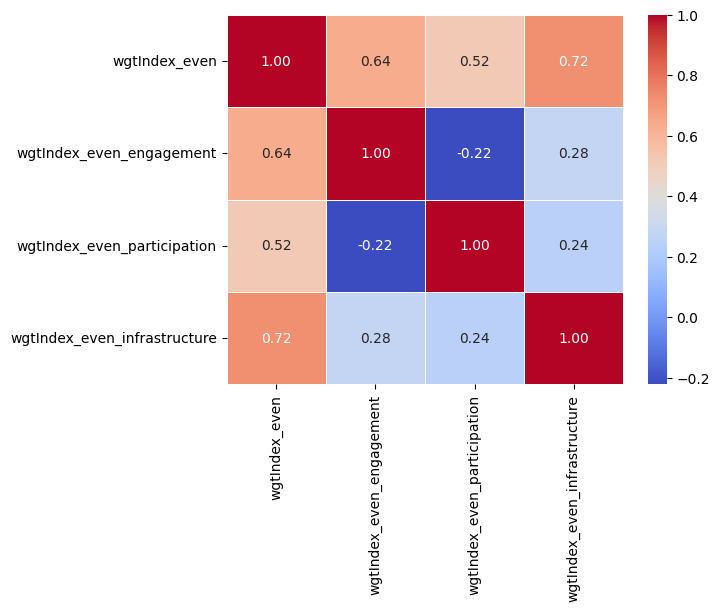

In [94]:
#analyze correlations between variables to determine which ones to use to forecast the number of active microbusinesses and microbusiness density
sns.heatmap(data = df_state_merge[['wgtIndex_even', 'wgtIndex_even_engagement', 'wgtIndex_even_participation', 'wgtIndex_even_infrastructure']].corr(), 
            annot = True, fmt = '.2f', linewidths=.5, cmap = "coolwarm");

In [124]:
df_state_merge.to_csv('microbusiness_state_data.csv', index = False)

## Correlation Analysis at the County Level

In [114]:
df_mai_countyLevel2 = df_mai_countyLevel.rename(columns = {'countyName' : 'county', 'date' : 'Date', 'county':'county_id'})
df_county_merge = pd.merge(df_county, df_mai_countyLevel2, on = ['Date', 'county'], how = 'outer')
df_county_merge.head()

,cfips,county,Date,Microbusinesses,Microbusiness Density,county_id,wgtIndex_baseline,wgtIndex_baseline_engagement,wgtIndex_baseline_participation,wgtIndex_baseline_infrastructure,wgtIndex_even,wgtIndex_even_engagement,wgtIndex_even_participation,wgtIndex_even_infrastructure,wgtIndex_simple
0,1001.0,"Autauga County, AL",2019-08-01,1249.0,2.985824,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1003.0,"Baldwin County, AL",2019-08-01,11464.0,7.057810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1005.0,"Barbour County, AL",2019-08-01,222.0,1.091124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1007.0,"Bibb County, AL",2019-08-01,234.0,1.309604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1009.0,"Blount County, AL",2019-08-01,681.0,1.541526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Heatmap for wgtIndex_even, wgtIndex_even_engagement, wgtIndex_even_participation, and wgtIndex_even_infrastructure.

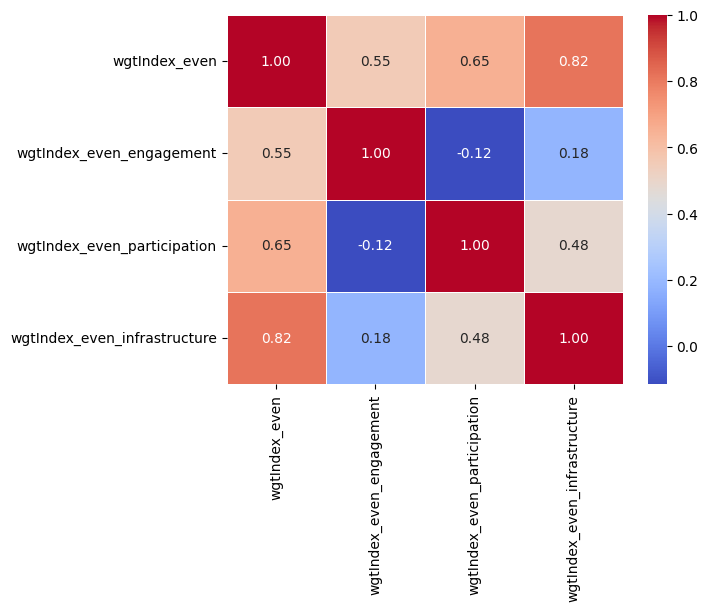

In [115]:
#analyze correlations between variables to determine which ones to use to forecast the number of active microbusinesses and microbusiness density
sns.heatmap(data = df_county_merge[['wgtIndex_even', 'wgtIndex_even_engagement', 'wgtIndex_even_participation', 'wgtIndex_even_infrastructure']].corr(), 
            annot = True, fmt = '.2f', linewidths=.5, cmap = "coolwarm");

In [123]:
df_county_merge.to_csv('microbusiness_county_data.csv', index = False)

## Correlation Analysis at the City Level

In [97]:
df_mai_cityLevel2 = df_mai_cityLevel.rename(columns = {'cbsaName' : 'city_name', 'date' : 'Date'})
df_city_merge = pd.merge(df_city, df_mai_cityLevel2, on = ['Date', 'city_name'], how = 'outer')
df_city_merge.head()

,cbsa_x,city_name,micro_metro,Date,Microbusinesses,Microbusiness Density,cbsa_y,wgtIndex_baseline,wgtIndex_baseline_engagement,wgtIndex_baseline_participation,wgtIndex_baseline_infrastructure,wgtIndex_even,wgtIndex_even_engagement,wgtIndex_even_participation,wgtIndex_even_infrastructure,wgtIndex_simple
0,49820.0,"Zapata, TX",Micropolitan Statistical Area,2019-08-01,35.0,0.367107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,46900.0,"Vernon, TX",Micropolitan Statistical Area,2019-08-01,104.0,1.040520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,22620.0,"Forrest City, AR",Micropolitan Statistical Area,2019-08-01,124.0,0.604259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25820.0,"Hereford, TX",Micropolitan Statistical Area,2019-08-01,123.0,0.948854,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,29500.0,"Lamesa, TX",Micropolitan Statistical Area,2019-08-01,176.0,1.795918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Heatmap for wgtIndex_even, wgtIndex_even_engagement, wgtIndex_even_participation, and wgtIndex_even_infrastructure.

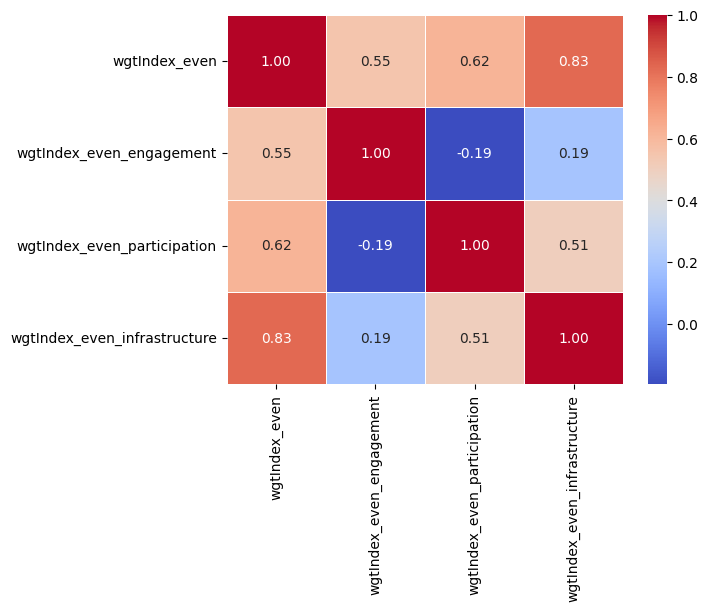

In [98]:
#analyze correlations between variables to determine which ones to use to forecast the number of active microbusinesses and microbusiness density
sns.heatmap(data = df_city_merge[['wgtIndex_even', 'wgtIndex_even_engagement', 'wgtIndex_even_participation', 'wgtIndex_even_infrastructure']].corr(), 
            annot = True, fmt = '.2f', linewidths=.5, cmap = "coolwarm");

In [122]:
df_city_merge.to_csv('microbusiness_city_data.csv', index = False)